# 电信公司客户流失模型-逻辑斯蒂

## 电信客户流失预测项目简介

本项目基于电信公司客户数据，构建逻辑回归模型，识别影响客户流失的关键因素，并对模型进行多角度评估。主要流程包括：

- 数据加载与清洗：去除重复、异常和缺失，变量标准化与编码。
- 多重共线性检验：通过VIF和相关系数热力图筛选特征，提升模型稳健性。
- 逻辑回归建模：输出完整统计量（系数、置信区间、p值、OR等），并可视化显著性。
- 预测与交叉验证：评估模型在测试集和交叉验证下的AUC、召回率、精确率、F1等指标。
- 结果解读与业务建议：结合统计与业务视角，提出针对性的客户挽留策略。

本项目旨在为电信企业提供科学的客户流失预警与干预依据，提升客户留存率和运营效率。

## 全流程图

```mermaid
flowchart TD
    A[1. 数据加载] --> B[2. 数据清洗]
    B --> C[3. 多重共线性检验 VIF]
    C --> D[4. 原模型建模]
    D --> D1[train/test split]
    D1 --> D2[标准化 StandardScaler]
    D2 --> D3[模型训练与测试集评估]
    D3 --> E[5. 原模型阈值选择]
    E --> E1[按阈值重算 Precision / Recall / F1]
    E1 --> E2[绘制最佳阈值混淆矩阵]
    E2 --> F[6. 重建模型建模]
    F --> F1[train/test split]
    F1 --> F2[标准化 StandardScaler]
    F2 --> F3[模型训练与测试集评估]
    F3 --> G[7. 重建模型阈值选择]
    G --> G1[按阈值重算 Precision / Recall / F1]
    G1 --> G2[绘制最佳阈值混淆矩阵]
    G2 --> H[8. 最终结果分析]
    H --> H1[默认阈值 vs 最佳阈值对比]
    H1 --> H2[业务结论与建议]

    B --> B1[缺失值 / 重复值 / 异常值检查]
    B --> B2[变量编码]
    B2 --> B3[生成特征集]
    C --> C1[删除高共线特征]
    C1 --> C2[保留最终特征]
    D --> D4[statsmodels 解释性回归]
    F --> F4[statsmodels 解释性回归]
```


## 1. 环境准备

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import warnings

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'PingFang SC']
plt.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings('ignore')

# 对齐中文字符
pd.set_option('display.unicode.east_asian_width', True)
pd.set_option('display.unicode.ambiguous_as_wide', True)

## 2. 数据加载

In [82]:
print("数据加载")
print("-" * 40)

df = pd.read_csv('customerchurn.csv')
print(f"原始数据维度: {df.shape[0]} 行 x {df.shape[1]} 列")
print("\n各字段类型:")
print(df.dtypes.to_string())
print("\n前5行预览:")
print(df.head())


数据加载
----------------------------------------
原始数据维度: 7032 行 x 7 列

各字段类型:
Churn                int64
MonthlyCharges     float64
SeniorCitizen        int64
PaymentMethod       object
InternetService     object
tenure               int64
Contract            object

前5行预览:
   Churn  MonthlyCharges  SeniorCitizen     PaymentMethod InternetService  \
0      0           29.85              0  Electronic check             DSL   
1      0           56.95              0      Mailed check             DSL   
2      1           53.85              0      Mailed check             DSL   
3      0           42.30              0     Bank transfer             DSL   
4      1           70.70              0  Electronic check     Fiber optic   

   tenure        Contract  
0       1  Month-to-month  
1      34        One year  
2       2  Month-to-month  
3      45        One year  
4       2  Month-to-month  


## 3. 数据清洗

In [83]:
print("数据清洗")
print("-" * 40)

print("缺失值检查:")
print(df.isnull().sum().to_string())

dup_count = df.duplicated().sum()
print(f"\n重复行数量: {dup_count}")
df = df.drop_duplicates()
print(f"去重后数据维度: {df.shape[0]} 行")

print("\n数值变量异常值检查（IQR法）:")
for col in ['MonthlyCharges', 'tenure']:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f"  {col}: IQR={IQR:.2f}, 正常范围=[{lower:.2f}, {upper:.2f}], 异常值={outliers}个")

print("\n分类变量值域核查:")
for col in ['PaymentMethod', 'InternetService', 'Contract']:
    print(f"  {col}: {sorted(df[col].unique().tolist())}")

print("\n变量编码:")
pay_dummies = pd.get_dummies(df['PaymentMethod'], prefix='Pay', drop_first=True)
print(f"  PaymentMethod -> One-Hot 编码 (基准类: Electronic check)")
print(f"  生成哑变量: {list(pay_dummies.columns)}")

internet_map = {'No': 0, 'DSL': 1, 'Fiber optic': 2}
contract_map = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
df['InternetService_enc'] = df['InternetService'].map(internet_map)
df['Contract_enc'] = df['Contract'].map(contract_map)
print(f"  InternetService -> 有序整数编码: {internet_map}")
print(f"  Contract -> 有序整数编码: {contract_map}")

df_model = pd.concat([df, pay_dummies], axis=1)
pay_cols = list(pay_dummies.columns)
all_feature_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges',
                    'InternetService_enc', 'Contract_enc'] + pay_cols
y = df_model['Churn']
print(f"\n初始特征集 ({len(all_feature_cols)} 个): {all_feature_cols}")

数据清洗
----------------------------------------
缺失值检查:
Churn              0
MonthlyCharges     0
SeniorCitizen      0
PaymentMethod      0
InternetService    0
tenure             0
Contract           0

重复行数量: 177
去重后数据维度: 6855 行

数值变量异常值检查（IQR法）:
  MonthlyCharges: IQR=50.40, 正常范围=[-35.92, 165.67], 异常值=0个
  tenure: IQR=47.00, 正常范围=[-61.50, 126.50], 异常值=0个

分类变量值域核查:
  PaymentMethod: ['Bank transfer', 'Credit card', 'Electronic check', 'Mailed check']
  InternetService: ['DSL', 'Fiber optic', 'No']
  Contract: ['Month-to-month', 'One year', 'Two year']

变量编码:
  PaymentMethod -> One-Hot 编码 (基准类: Electronic check)
  生成哑变量: ['Pay_Credit card', 'Pay_Electronic check', 'Pay_Mailed check']
  InternetService -> 有序整数编码: {'No': 0, 'DSL': 1, 'Fiber optic': 2}
  Contract -> 有序整数编码: {'Month-to-month': 0, 'One year': 1, 'Two year': 2}

初始特征集 (8 个): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'InternetService_enc', 'Contract_enc', 'Pay_Credit card', 'Pay_Electronic check', 'Pay_Mailed check']


## 4. 多重共线性检验

多重共线性检验（VIF）
----------------------------------------
判断标准: VIF < 5 = 正常; 5~10 = 中度; > 10 = 严重

第1轮 VIF（全量特征）:
特征                   VIF      判断  
      MonthlyCharges   39.4353  严重  
 InternetService_enc   28.3283  严重  
              tenure    6.4382  中度  
        Contract_enc    3.9100  正常  
Pay_Electronic check    2.1900  正常  
     Pay_Credit card    1.6368  正常  
    Pay_Mailed check    1.3420  正常  
       SeniorCitizen    1.3062  正常  


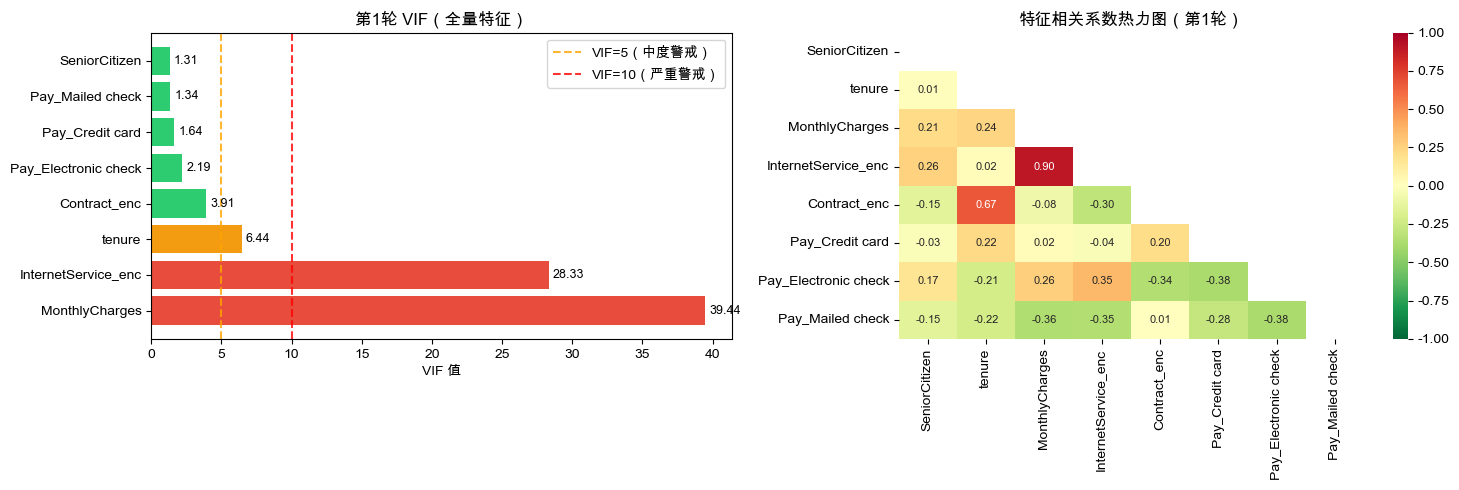


决策: 删除 MonthlyCharges
原因: MonthlyCharges VIF=39.4，与 InternetService_enc 相关系数约 r=0.90，严重共线。
      保留 InternetService_enc（业务含义更直接）。

第2轮 VIF（删除 MonthlyCharges 后）:
特征                   VIF      判断  
              tenure   5.6093   中度  
        Contract_enc   3.7299   正常  
 InternetService_enc   3.7147   正常  
Pay_Electronic check   2.1091   正常  
     Pay_Credit card   1.5904   正常  
       SeniorCitizen   1.3058   正常  
    Pay_Mailed check   1.2472   正常  


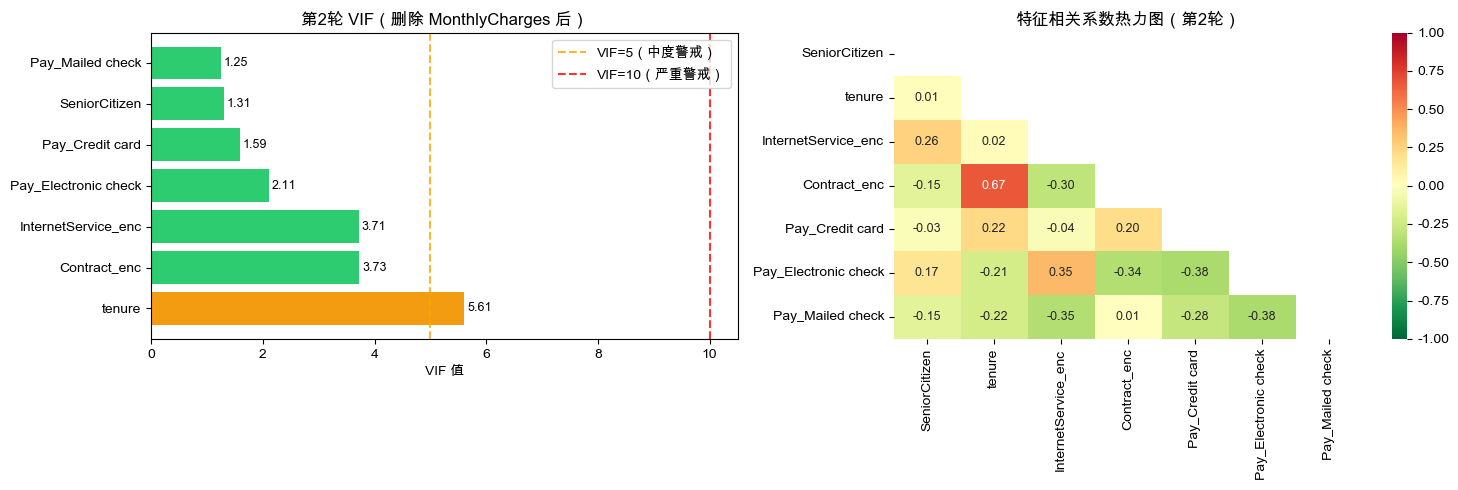


最终特征集 (7 个): ['SeniorCitizen', 'tenure', 'InternetService_enc', 'Contract_enc', 'Pay_Credit card', 'Pay_Electronic check', 'Pay_Mailed check']


In [98]:
print("多重共线性检验（VIF）")
print("-" * 40)
print("判断标准: VIF < 5 = 正常; 5~10 = 中度; > 10 = 严重")

def compute_vif(X):
    vif = pd.DataFrame()
    vif['特征'] = X.columns
    vif['VIF'] = [variance_inflation_factor(X.values.astype(float), i)
                  for i in range(X.shape[1])]
    vif['判断'] = vif['VIF'].apply(
        lambda v: '正常' if v < 5 else ('中度' if v < 10 else '严重'))
    return vif.sort_values('VIF', ascending=False).reset_index(drop=True)

def print_vif_table(vif_df):
    print(vif_df.to_string(
        index=False,
        justify='left',
        col_space={'特征': 22, 'VIF': 8, '判断': 6},
        formatters={'VIF': lambda x: f'{x:.4f}'}
    ))

X_all = df_model[all_feature_cols].astype(float)
vif1 = compute_vif(X_all)
print("\n第1轮 VIF（全量特征）:")
print_vif_table(vif1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
colors1 = ['#e74c3c' if v > 10 else '#f39c12' if v > 5 else '#2ecc71' for v in vif1['VIF']]
bars = axes[0].barh(vif1['特征'], vif1['VIF'], color=colors1)
axes[0].axvline(x=5,  color='orange', linestyle='--', alpha=0.8, label='VIF=5（中度警戒）')
axes[0].axvline(x=10, color='red',    linestyle='--', alpha=0.8, label='VIF=10（严重警戒）')
axes[0].set_xlabel('VIF 值')
axes[0].set_title('第1轮 VIF（全量特征）')
axes[0].legend()
for bar, val in zip(bars, vif1['VIF']):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=9)
corr1 = X_all.corr()
mask = np.triu(np.ones_like(corr1, dtype=bool))
sns.heatmap(corr1, annot=True, fmt='.2f', cmap='RdYlGn_r', mask=mask,
            ax=axes[1], annot_kws={'size': 8}, vmin=-1, vmax=1, center=0)
axes[1].set_title('特征相关系数热力图（第1轮）')
plt.tight_layout()
plt.show()

X_reduced = X_all.drop(columns=['MonthlyCharges'])
print(f"\n决策: 删除 MonthlyCharges")
print("原因: MonthlyCharges VIF=39.4，与 InternetService_enc 相关系数约 r=0.90，严重共线。")
print("      保留 InternetService_enc（业务含义更直接）。")

vif2 = compute_vif(X_reduced)
print("\n第2轮 VIF（删除 MonthlyCharges 后）:")
print_vif_table(vif2)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
colors2 = ['#e74c3c' if v > 10 else '#f39c12' if v > 5 else '#2ecc71' for v in vif2['VIF']]
bars2 = axes[0].barh(vif2['特征'], vif2['VIF'], color=colors2)
axes[0].axvline(x=5,  color='orange', linestyle='--', alpha=0.8, label='VIF=5（中度警戒）')
axes[0].axvline(x=10, color='red',    linestyle='--', alpha=0.8, label='VIF=10（严重警戒）')
axes[0].set_xlabel('VIF 值')
axes[0].set_title('第2轮 VIF（删除 MonthlyCharges 后）')
axes[0].legend()
for bar, val in zip(bars2, vif2['VIF']):
    axes[0].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=9)
corr2 = X_reduced.corr()
mask2 = np.triu(np.ones_like(corr2, dtype=bool))
sns.heatmap(corr2, annot=True, fmt='.2f', cmap='RdYlGn_r', mask=mask2,
            ax=axes[1], annot_kws={'size': 9}, vmin=-1, vmax=1, center=0)
axes[1].set_title('特征相关系数热力图（第2轮）')
plt.tight_layout()
plt.show()

final_feature_cols = list(X_reduced.columns)
print(f"\n最终特征集 ({len(final_feature_cols)} 个): {final_feature_cols}")


## 5. 原模型Logistic 回归建模

### 5.1. Logistic回归建模（7个特征）

Logistic 回归建模（含完整统计量）
----------------------------------------

回归结果（含统计量）:
变量                     系数 B       标准误 SE    z 值         p 值         显著性   OR           95%CI 下限   95%CI 上限  
               const     -1.6093      0.0446       -36.0520     0.0000       ***      0.2000       0.1833       0.2183      
       SeniorCitizen      0.1289      0.0303         4.2526     0.0000       ***      1.1376       1.0720       1.2072      
              tenure     -0.7479      0.0490       -15.2674     0.0000       ***      0.4734       0.4300       0.5211      
 InternetService_enc      0.7782      0.0436        17.8590     0.0000       ***      2.1775       1.9993       2.3717      
        Contract_enc     -0.6208      0.0617       -10.0653     0.0000       ***      0.5375       0.4763       0.6066      
     Pay_Credit card     -0.0263      0.0464        -0.5677     0.5702        ns      0.9740       0.8894       1.0667      
Pay_Electronic check      0.1998      0.0439         4.5502     0

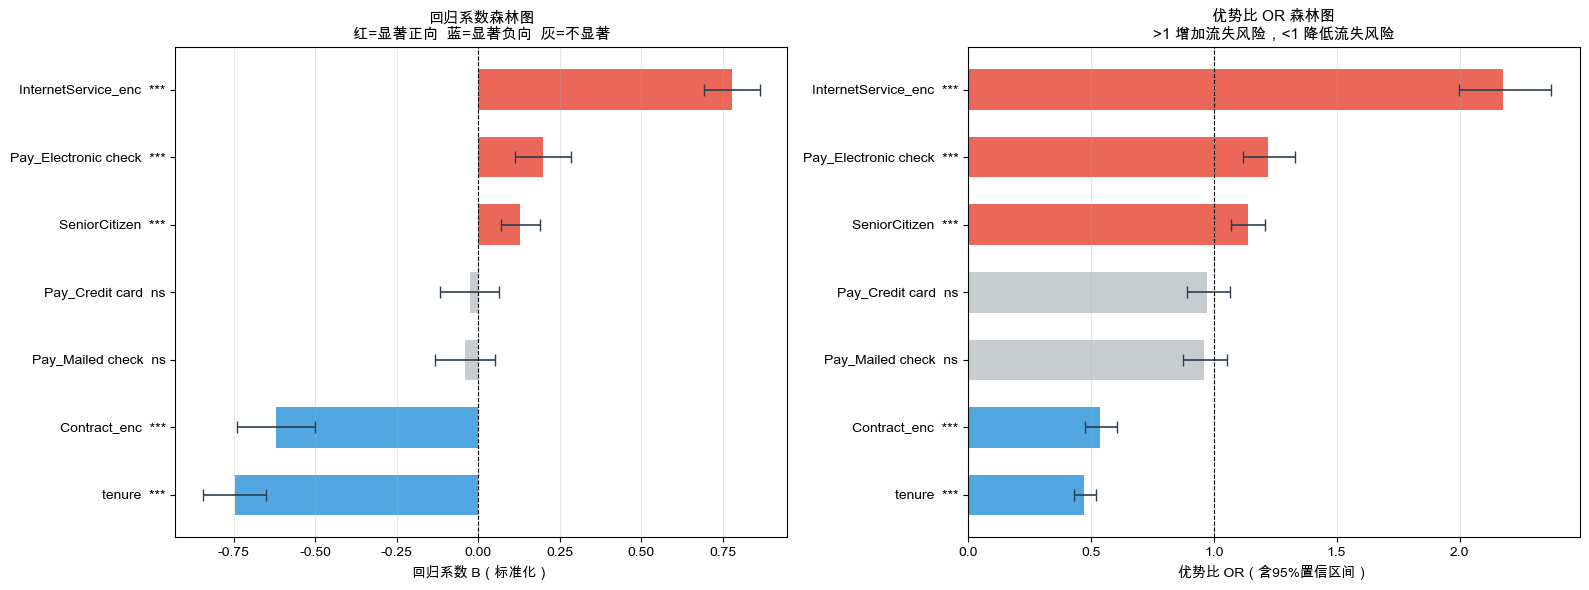

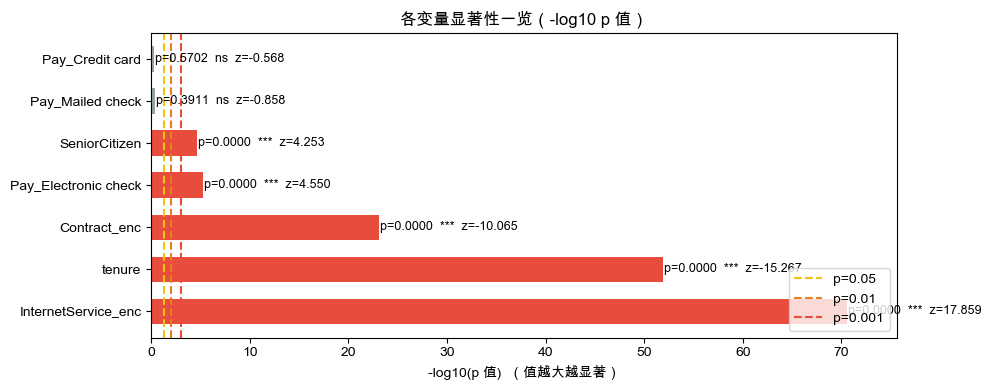

In [99]:
print("Logistic 回归建模（含完整统计量）")
print("-" * 40)

# 0) 使用VIF筛选后的最终特征，进入原模型建模
X = df_model[final_feature_cols].astype(float)

# 1) 为statsmodels做标准化并添加常数项（截距）
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)
X_sm = sm.add_constant(X_sc)
col_names_sm = ['const'] + final_feature_cols

# 2) 拟合Logit模型（全样本）以获取完整统计量
logit_model = sm.Logit(y, X_sm)
result = logit_model.fit(disp=False)

# 3) 汇总系数、显著性与OR等统计信息
coef_vals  = result.params.values
std_errs   = result.bse.values
z_vals     = result.tvalues.values
p_vals     = result.pvalues.values
ci_low     = result.conf_int().iloc[:, 0].values
ci_high    = result.conf_int().iloc[:, 1].values
or_vals    = np.exp(coef_vals)

def sig_label(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    elif p < 0.1: return '.'
    else: return 'ns'

stat_df = pd.DataFrame({
    '变量':       col_names_sm,
    '系数 B':     coef_vals,
    '标准误 SE':  std_errs,
    'z 值':       z_vals,
    'p 值':       p_vals,
    '显著性':     [sig_label(p) for p in p_vals],
    'OR':         or_vals,
    '95%CI 下限': np.exp(ci_low),
    '95%CI 上限': np.exp(ci_high),
})

# 统一中文宽字符表格对齐输出
def print_aligned_table(df, float_digits=4):
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    formatters = {c: (lambda x, d=float_digits: f'{x:.{d}f}') for c in numeric_cols}
    col_space = {c: 12 for c in df.columns}
    if '变量' in col_space:
        col_space['变量'] = 24
    if '显著性' in col_space:
        col_space['显著性'] = 8
    print(df.to_string(index=False, justify='left', col_space=col_space, formatters=formatters))

print("\n回归结果（含统计量）:")
print_aligned_table(stat_df)
print("\n显著性标注说明: *** p<0.001  ** p<0.01  * p<0.05  . p<0.1  ns 不显著")

# 4) 输出模型整体拟合优度指标
print(f"\n模型整体拟合指标:")
print(f"  观测数:          {int(result.nobs)}")
print(f"  对数似然值:      {result.llf:.4f}")
print(f"  McFadden R²:     {result.prsquared:.4f}")
print(f"  AIC:             {result.aic:.4f}")
print(f"  BIC:             {result.bic:.4f}")
print(f"  LR 检验 p 值:    {result.llr_pvalue:.2e}")

# 5) 分开输出显著与不显著变量，便于后续重建模
sig_vars = stat_df[stat_df['变量'] != 'const'][
    stat_df[stat_df['变量'] != 'const']['p 值'] < 0.05]
insig_vars = stat_df[stat_df['变量'] != 'const'][
    stat_df[stat_df['变量'] != 'const']['p 值'] >= 0.05]
print(f"\n显著变量（p < 0.05）:")
print_aligned_table(sig_vars[['变量','系数 B','z 值','p 值','显著性','OR']])
print(f"\n不显著变量（p >= 0.05）:")
print_aligned_table(insig_vars[['变量','系数 B','z 值','p 值','显著性','OR']])

# 6) 双图可视化：系数森林图 + OR森林图
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_df = stat_df[stat_df['变量'] != 'const'].copy()
plot_df['ci_low_raw']  = result.conf_int().iloc[1:, 0].values
plot_df['ci_high_raw'] = result.conf_int().iloc[1:, 1].values
plot_df['significant'] = plot_df['p 值'] < 0.05
plot_df = plot_df.sort_values('系数 B')

colors_sig = ['#e74c3c' if (sig and b > 0) else '#3498db' if (sig and b <= 0)
              else '#bdc3c7'
              for sig, b in zip(plot_df['significant'], plot_df['系数 B'])]

y_pos = range(len(plot_df))
axes[0].barh(y_pos, plot_df['系数 B'], color=colors_sig, height=0.6, alpha=0.85)
axes[0].errorbar(plot_df['系数 B'], y_pos,
                 xerr=[plot_df['系数 B'] - plot_df['ci_low_raw'],
                       plot_df['ci_high_raw'] - plot_df['系数 B']],
                 fmt='none', color='#2c3e50', capsize=4, linewidth=1.2)
axes[0].axvline(x=0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels([
    f"{row['变量']}  {row['显著性']}" for _, row in plot_df.iterrows()
], fontsize=10)
axes[0].set_xlabel('回归系数 B（标准化）')
axes[0].set_title('回归系数森林图\n红=显著正向  蓝=显著负向  灰=不显著', fontsize=11)
axes[0].grid(axis='x', alpha=0.3)

plot_df_or = plot_df.sort_values('OR')
y_pos2 = range(len(plot_df_or))
colors_or = ['#e74c3c' if (sig and o > 1) else '#3498db' if (sig and o <= 1)
             else '#bdc3c7'
             for sig, o in zip(plot_df_or['significant'], plot_df_or['OR'])]
axes[1].barh(y_pos2, plot_df_or['OR'], color=colors_or, height=0.6, alpha=0.85)
axes[1].errorbar(plot_df_or['OR'], y_pos2,
                 xerr=[plot_df_or['OR'] - plot_df_or['95%CI 下限'],
                       plot_df_or['95%CI 上限'] - plot_df_or['OR']],
                 fmt='none', color='#2c3e50', capsize=4, linewidth=1.2)
axes[1].axvline(x=1, color='black', linewidth=0.8, linestyle='--')
axes[1].set_yticks(y_pos2)
axes[1].set_yticklabels([
    f"{row['变量']}  {row['显著性']}" for _, row in plot_df_or.iterrows()
], fontsize=10)
axes[1].set_xlabel('优势比 OR（含95%置信区间）')
axes[1].set_title('优势比 OR 森林图\n>1 增加流失风险，<1 降低流失风险', fontsize=11)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# 7) p值显著性热图，直观看变量统计显著程度
fig, ax = plt.subplots(figsize=(10, 4))
plot_p = stat_df[stat_df['变量'] != 'const'][['变量', 'p 值', '显著性', 'z 值', '系数 B']].copy()
plot_p = plot_p.sort_values('p 值')
bar_colors_p = ['#e74c3c' if p < 0.001 else '#e67e22' if p < 0.01
                else '#f1c40f' if p < 0.05 else '#95a5a6' for p in plot_p['p 值']]
bars_p = ax.barh(plot_p['变量'], -np.log10(plot_p['p 值'].clip(lower=1e-300)),
                 color=bar_colors_p, height=0.6)
ax.axvline(x=-np.log10(0.05),  color='#f1c40f', linestyle='--', linewidth=1.5,
           label='p=0.05')
ax.axvline(x=-np.log10(0.01),  color='#e67e22', linestyle='--', linewidth=1.5,
           label='p=0.01')
ax.axvline(x=-np.log10(0.001), color='#e74c3c', linestyle='--', linewidth=1.5,
           label='p=0.001')
for bar, (_, row) in zip(bars_p, plot_p.iterrows()):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f"p={row['p 值']:.4f}  {row['显著性']}  z={row['z 值']:.3f}",
            va='center', fontsize=9)
ax.set_xlabel('-log10(p 值)  （值越大越显著）')
ax.set_title('各变量显著性一览（-log10 p 值）')
ax.legend(loc='lower right')
ax.set_xlim(0, max(-np.log10(plot_p['p 值'].clip(lower=1e-300))) + 5)
plt.tight_layout()
plt.show()

### 5.2. 模型评估与交叉验证

原模型预测评估与交叉验证（7个原始特征）
----------------------------------------
使用特征: ['SeniorCitizen', 'tenure', 'InternetService_enc', 'Contract_enc', 'Pay_Credit card', 'Pay_Electronic check', 'Pay_Mailed check']
测试集 AUC-ROC: 0.8438
决策阈值: 0.35
当前阈值对应: TPR=0.9134, FPR=0.4339

分类报告（测试集）:
类别         precision  recall     f1-score   support 
      未流失 0.9480     0.5661     0.7089     1514    
        流失 0.4302     0.9134     0.5849      543    
   macro avg 0.6891     0.7397     0.6469     2057    
weighted avg 0.8113     0.6578     0.6761     2057    

Accuracy: 0.6578

候选阈值 TPR/FPR 一览（测试集）:
阈值     TPR        FPR       
0.30     0.9374     0.4914    
0.35     0.9134     0.4339    
0.40     0.8711     0.3838    
0.50     0.8306     0.3078    
0.60     0.7366     0.2087    

5折交叉验证结果（流失类）:
折次     AUC        召回率     精确率     F1        
 第1折   0.8350     0.7867     0.4931     0.6062    
 第2折   0.8468     0.8310     0.5017     0.6257    
 第3折   0.8194     0.7873     0.4750     0.5925    
 第4折   0.8510     0.8

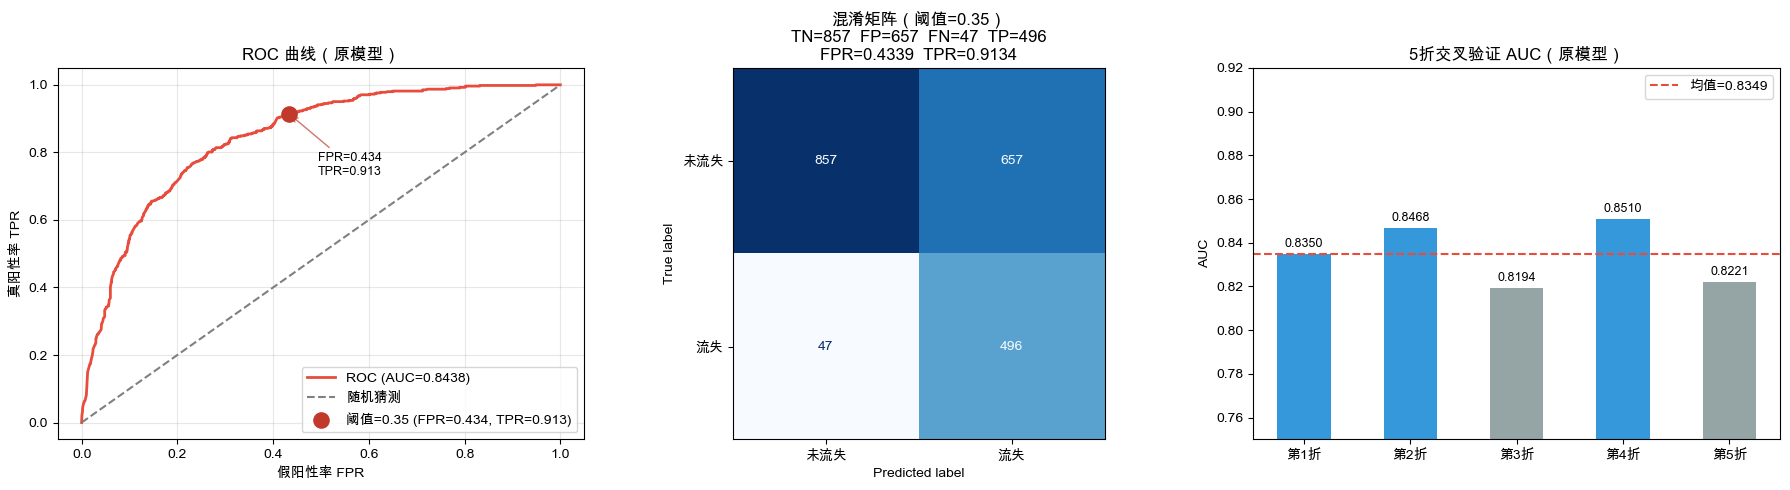

In [94]:
print("原模型预测评估与交叉验证（7个原始特征）")
print("-" * 40)

from sklearn.linear_model import LogisticRegression

# 0) 固定原模型评估使用的特征集合，保证可复现对比
original_feature_cols = [
    'SeniorCitizen',
    'tenure',
    'InternetService_enc',
    'Contract_enc',
    'Pay_Credit card',
    'Pay_Electronic check',
    'Pay_Mailed check'
]
X_eval_base = df_model[original_feature_cols].astype(float).copy()
print(f"使用特征: {list(X_eval_base.columns)}")

# 1) 分层抽样划分训练/测试，保持流失占比一致
X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_eval_base, y, test_size=0.3, random_state=42, stratify=y)

# 2) 使用Pipeline将标准化与模型绑定，避免数据泄漏
cv_base = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
base_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'))
])

# 3) 训练后输出测试集概率，用于AUC与阈值分析
base_pipe.fit(X_train_base, y_train_base)
y_pred_proba_base = base_pipe.predict_proba(X_test_base)[:, 1]
auc_test_base = roc_auc_score(y_test_base, y_pred_proba_base)

# 4) 先按默认业务阈值评估（与后续阈值优化分开）
THRESHOLD_BASE = 0.35
y_pred_base = (y_pred_proba_base >= THRESHOLD_BASE).astype(int)

# 5) 计算当前阈值下的混淆矩阵与TPR/FPR
cm_base = confusion_matrix(y_test_base, y_pred_base)
tn_base, fp_base, fn_base, tp_base = cm_base.ravel()
tpr_base_at_threshold = tp_base / (tp_base + fn_base) if (tp_base + fn_base) > 0 else 0.0
fpr_base_at_threshold = fp_base / (fp_base + tn_base) if (fp_base + tn_base) > 0 else 0.0

print(f"测试集 AUC-ROC: {auc_test_base:.4f}")
print(f"决策阈值: {THRESHOLD_BASE}")
print(f"当前阈值对应: TPR={tpr_base_at_threshold:.4f}, FPR={fpr_base_at_threshold:.4f}")
print("\n分类报告（测试集）:")
report_dict_base = classification_report(
    y_test_base, y_pred_base, target_names=['未流失', '流失'], output_dict=True
)
accuracy_test_base = report_dict_base.pop('accuracy')
cls_report_df_base = pd.DataFrame(report_dict_base).T
cls_report_df_base.index.name = '类别'
cls_report_df_base = cls_report_df_base.reset_index()
print(cls_report_df_base.to_string(
    index=False,
    justify='left',
    col_space={'类别': 12, 'precision': 10, 'recall': 10, 'f1-score': 10, 'support': 8},
    formatters={
        'precision': lambda x: f'{x:.4f}' if isinstance(x, (float, np.floating)) else x,
        'recall': lambda x: f'{x:.4f}' if isinstance(x, (float, np.floating)) else x,
        'f1-score': lambda x: f'{x:.4f}' if isinstance(x, (float, np.floating)) else x,
        'support': lambda x: f'{int(round(x))}' if isinstance(x, (float, np.floating, int, np.integer)) else x
    }
) )
print(f"\nAccuracy: {accuracy_test_base:.4f}")

# 6) 给出几个候选阈值对应的TPR/FPR，便于业务选择操作点
threshold_candidates_base = [0.30, 0.35, 0.40, 0.50, 0.60]
rows_tpr_fpr_base = []
for th in threshold_candidates_base:
    y_pred_th = (y_pred_proba_base >= th).astype(int)
    tn_th, fp_th, fn_th, tp_th = confusion_matrix(y_test_base, y_pred_th).ravel()
    tpr_th = tp_th / (tp_th + fn_th) if (tp_th + fn_th) > 0 else 0.0
    fpr_th = fp_th / (fp_th + tn_th) if (fp_th + tn_th) > 0 else 0.0
    rows_tpr_fpr_base.append([th, tpr_th, fpr_th])
tpr_fpr_table_base = pd.DataFrame(rows_tpr_fpr_base, columns=['阈值', 'TPR', 'FPR'])
print("\n候选阈值 TPR/FPR 一览（测试集）:")
print(tpr_fpr_table_base.to_string(
    index=False,
    justify='left',
    col_space={'阈值': 8, 'TPR': 10, 'FPR': 10},
    formatters={
        '阈值': lambda x: f'{x:.2f}',
        'TPR': lambda x: f'{x:.4f}',
        'FPR': lambda x: f'{x:.4f}'
    }
) )

# 7) 用训练集OOF概率做阈值学习，避免在测试集上“挑阈值”
y_train_oof_proba_base = cross_val_predict(
    base_pipe, X_train_base, y_train_base, cv=cv_base, method='predict_proba'
)[:, 1]

# 8) 做5折CV，检验模型在不同抽样下的稳定性
cv_auc_base = cross_val_score(base_pipe, X_eval_base, y, cv=cv_base, scoring='roc_auc')
cv_rec_base = cross_val_score(base_pipe, X_eval_base, y, cv=cv_base, scoring='recall')
cv_prec_base = cross_val_score(base_pipe, X_eval_base, y, cv=cv_base, scoring='precision')
cv_f1_base = cross_val_score(base_pipe, X_eval_base, y, cv=cv_base, scoring='f1')

print("\n5折交叉验证结果（流失类）:")
rows_base = []
for i in range(5):
    rows_base.append([f'第{i+1}折', cv_auc_base[i], cv_rec_base[i], cv_prec_base[i], cv_f1_base[i]])
rows_base.append(['均值', cv_auc_base.mean(), cv_rec_base.mean(), cv_prec_base.mean(), cv_f1_base.mean()])
rows_base.append(['标准差', cv_auc_base.std(), cv_rec_base.std(), cv_prec_base.std(), cv_f1_base.std()])
cv_table_base = pd.DataFrame(rows_base, columns=['折次', 'AUC', '召回率', '精确率', 'F1'])
print(cv_table_base.to_string(
    index=False,
    justify='left',
    col_space={'折次': 8, 'AUC': 10, '召回率': 10, '精确率': 10, 'F1': 10},
    formatters={
        'AUC': lambda x: f'{x:.4f}' if isinstance(x, (float, np.floating)) else x,
        '召回率': lambda x: f'{x:.4f}' if isinstance(x, (float, np.floating)) else x,
        '精确率': lambda x: f'{x:.4f}' if isinstance(x, (float, np.floating)) else x,
        'F1': lambda x: f'{x:.4f}' if isinstance(x, (float, np.floating)) else x
    }
) )

# 9) 一图汇总：ROC + 混淆矩阵 + CV AUC
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fpr_base, tpr_base, thresholds_roc_base = roc_curve(y_test_base, y_pred_proba_base)
axes[0].plot(fpr_base, tpr_base, color='#e74c3c', lw=2, label=f'ROC (AUC={auc_test_base:.4f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', label='随机猜测')
idx_base = np.argmin(np.abs(thresholds_roc_base - THRESHOLD_BASE))
axes[0].scatter(
    fpr_base_at_threshold, tpr_base_at_threshold, s=120, color='#c0392b', zorder=5,
    label=f'阈值={THRESHOLD_BASE} (FPR={fpr_base_at_threshold:.3f}, TPR={tpr_base_at_threshold:.3f})'
 )
axes[0].annotate(
    f'FPR={fpr_base_at_threshold:.3f}\nTPR={tpr_base_at_threshold:.3f}',
    xy=(fpr_base_at_threshold, tpr_base_at_threshold),
    xytext=(fpr_base_at_threshold + 0.06, max(0.05, tpr_base_at_threshold - 0.18)),
    arrowprops=dict(arrowstyle='->', color='#c0392b', alpha=0.7),
    fontsize=9
 )
axes[0].set_xlabel('假阳性率 FPR')
axes[0].set_ylabel('真阳性率 TPR')
axes[0].set_title('ROC 曲线（原模型）')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

disp_base = ConfusionMatrixDisplay(confusion_matrix=cm_base, display_labels=['未流失', '流失'])
disp_base.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(
    f'混淆矩阵（阈值={THRESHOLD_BASE}）\nTN={tn_base}  FP={fp_base}  FN={fn_base}  TP={tp_base}\n'
    f'FPR={fpr_base_at_threshold:.4f}  TPR={tpr_base_at_threshold:.4f}'
)

fold_labels_base = [f'第{i+1}折' for i in range(5)]
bar_cols_base = ['#3498db' if v >= cv_auc_base.mean() else '#95a5a6' for v in cv_auc_base]
axes[2].bar(fold_labels_base, cv_auc_base, color=bar_cols_base, width=0.5)
axes[2].axhline(y=cv_auc_base.mean(), color='#e74c3c', linestyle='--',
                label=f'均值={cv_auc_base.mean():.4f}')
axes[2].set_ylim(0.75, 0.92)
axes[2].set_ylabel('AUC')
axes[2].set_title('5折交叉验证 AUC（原模型）')
axes[2].legend()
for i, v in enumerate(cv_auc_base):
    axes[2].text(i, v + 0.003, f'{v:.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### 5.3. 原模型阈值选择（Precision / Recall / F1）

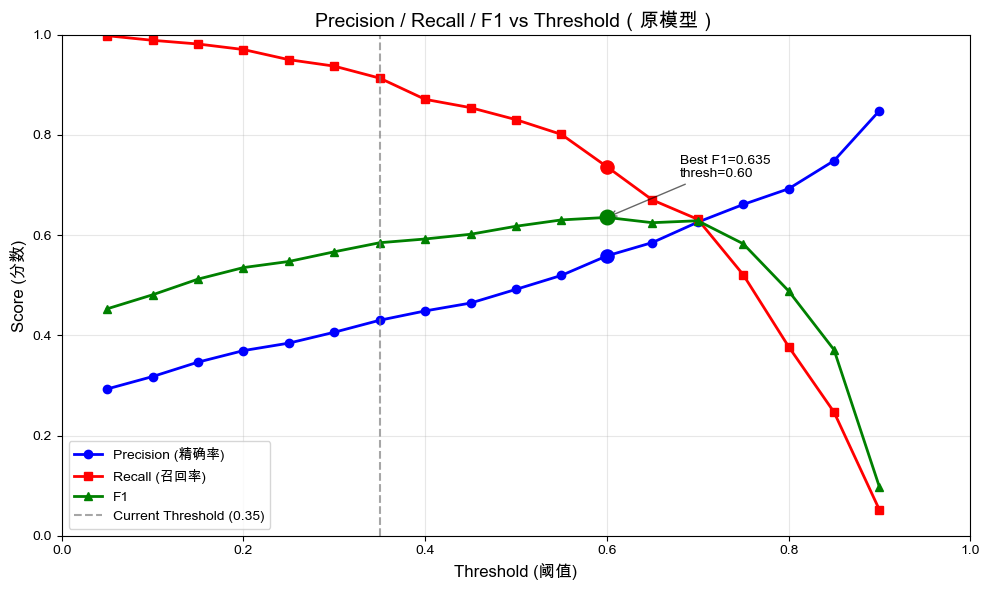

当前评估对象: 原模型
最佳F1阈值: 0.60
此时精确率: 0.559, 召回率: 0.737, F1: 0.635

Top-3 阈值（按 F1 排序）:
1. 阈值=0.60 | Precision=0.559 | Recall=0.737 | F1=0.635
2. 阈值=0.55 | Precision=0.520 | Recall=0.801 | F1=0.630
3. 阈值=0.70 | Precision=0.626 | Recall=0.632 | F1=0.629


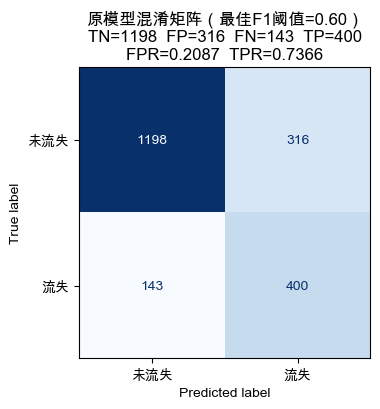


原模型四档风险分层：
风险档位   概率区间               定义依据             
  高风险          P >= 0.70       precision >= 60% 锚点
较高风险   0.60 <= P < 0.70                F1 最高 锚点
中等风险   0.35 <= P < 0.60             recall 90% 锚点
  低风险           P < 0.35                最低风险区间

测试集样本分布：
高风险      548
较高风险    168
中等风险    437
低风险      904


In [92]:
from sklearn.metrics import precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

# 原模型阈值分析：固定使用原模型测试集概率
if 'y_test_base' not in globals() or 'y_pred_proba_base' not in globals():
    raise NameError('未找到原模型评估结果，请先运行原模型评估单元（5.2）。')

y_true_base = y_test_base
y_prob_base = y_pred_proba_base
current_thresh_base = THRESHOLD_BASE if 'THRESHOLD_BASE' in globals() else 0.35

# 1) 在候选阈值网格上逐点扫描 Precision / Recall / F1
thresholds_base = np.arange(0.05, 0.95, 0.05)
precisions_base = []
recalls_base = []
f1_scores_base = []

for thresh in thresholds_base:
    y_pred_base_tmp = (y_prob_base >= thresh).astype(int)
    p_base = precision_score(y_true_base, y_pred_base_tmp, zero_division=0)
    r_base = recall_score(y_true_base, y_pred_base_tmp, zero_division=0)
    f1_base = 2 * p_base * r_base / (p_base + r_base) if (p_base + r_base) > 0 else 0
    precisions_base.append(p_base)
    recalls_base.append(r_base)
    f1_scores_base.append(f1_base)

# 2) 以 F1 最大点作为“综合平衡”推荐阈值
best_idx_base = int(np.argmax(f1_scores_base))
best_thresh_base = float(thresholds_base[best_idx_base])

# 3) 同图展示三条曲线 + 当前业务阈值 + 最佳F1阈值
plt.figure(figsize=(10, 6))
plt.plot(thresholds_base, precisions_base, 'b-', marker='o', label='Precision (精确率)', linewidth=2)
plt.plot(thresholds_base, recalls_base, 'r-', marker='s', label='Recall (召回率)', linewidth=2)
plt.plot(thresholds_base, f1_scores_base, 'g-', marker='^', label='F1', linewidth=2)

plt.axvline(
    x=current_thresh_base,
    color='gray',
    linestyle='--',
    alpha=0.7,
    label=f'Current Threshold ({current_thresh_base:.2f})'
 )

plt.scatter(best_thresh_base, precisions_base[best_idx_base], color='blue', s=90, zorder=5)
plt.scatter(best_thresh_base, recalls_base[best_idx_base], color='red', s=90, zorder=5)
plt.scatter(best_thresh_base, f1_scores_base[best_idx_base], color='green', s=110, zorder=6)
plt.annotate(
    f'Best F1={f1_scores_base[best_idx_base]:.3f}\nthresh={best_thresh_base:.2f}',
    xy=(best_thresh_base, f1_scores_base[best_idx_base]),
    xytext=(best_thresh_base + 0.08, min(0.98, f1_scores_base[best_idx_base] + 0.08)),
    arrowprops=dict(arrowstyle='->', color='black', alpha=0.6),
    fontsize=10
 )

plt.xlabel('Threshold (阈值)', fontsize=12)
plt.ylabel('Score (分数)', fontsize=12)
plt.title('Precision / Recall / F1 vs Threshold（原模型）', fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print('当前评估对象: 原模型')
print(f'最佳F1阈值: {best_thresh_base:.2f}')
print(f'此时精确率: {precisions_base[best_idx_base]:.3f}, 召回率: {recalls_base[best_idx_base]:.3f}, F1: {f1_scores_base[best_idx_base]:.3f}')

# 4) 给出Top-3阈值，便于在召回与精确率间做业务折中
top_idx_base = np.argsort(f1_scores_base)[::-1][:3]
print('\nTop-3 阈值（按 F1 排序）:')
for rank, idx in enumerate(top_idx_base, start=1):
    print(
        f'{rank}. 阈值={thresholds_base[idx]:.2f} | Precision={precisions_base[idx]:.3f} | Recall={recalls_base[idx]:.3f} | F1={f1_scores_base[idx]:.3f}'
    )

# 5) 用最佳阈值重算混淆矩阵，并直接报告 TPR/FPR
y_pred_base_best = (y_prob_base >= best_thresh_base).astype(int)
cm_base_best = confusion_matrix(y_true_base, y_pred_base_best)
tn_base_best, fp_base_best, fn_base_best, tp_base_best = cm_base_best.ravel()
tpr_base_best = tp_base_best / (tp_base_best + fn_base_best) if (tp_base_best + fn_base_best) > 0 else 0.0
fpr_base_best = fp_base_best / (fp_base_best + tn_base_best) if (fp_base_best + tn_base_best) > 0 else 0.0
fig, ax = plt.subplots(figsize=(5.2, 4.2))
disp_base_best = ConfusionMatrixDisplay(confusion_matrix=cm_base_best, display_labels=['未流失', '流失'])
disp_base_best.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'原模型混淆矩阵（最佳F1阈值={best_thresh_base:.2f}）\nTN={tn_base_best}  FP={fp_base_best}  FN={fn_base_best}  TP={tp_base_best}\nFPR={fpr_base_best:.4f}  TPR={tpr_base_best:.4f}')
plt.tight_layout()
plt.show()

# 6) 基于 recall90 / F1最优 / precision60 三个位点，切分四档风险
recall_target_base = 0.90
precision_target_base = 0.60
recall_candidates_base = np.where(np.array(recalls_base) >= recall_target_base)[0]
precision_candidates_base = np.where(np.array(precisions_base) >= precision_target_base)[0]
recall90_idx_base = int(recall_candidates_base.max()) if len(recall_candidates_base) else int(np.argmax(recalls_base))
precision60_idx_base = int(precision_candidates_base.min()) if len(precision_candidates_base) else int(np.argmax(precisions_base))
f1_best_idx_base = best_idx_base
anchor_thresholds_base = {
    'recall_90': float(thresholds_base[recall90_idx_base]),
    'f1_best': float(thresholds_base[f1_best_idx_base]),
    'precision_60': float(thresholds_base[precision60_idx_base]),
}
anchor_order_base = sorted(anchor_thresholds_base.items(), key=lambda kv: kv[1])
ordered_threshold_values_base = [v for _, v in anchor_order_base]
if ordered_threshold_values_base != [anchor_thresholds_base['recall_90'], anchor_thresholds_base['f1_best'], anchor_thresholds_base['precision_60']]:
    print('\n提示：当前三个位点的顺序不是 recall90 < F1最佳 < precision60，已按数值顺序重排分层边界。')
low_cut_base, mid_cut_base, high_cut_base = ordered_threshold_values_base
risk_labels_base = np.select(
    [y_prob_base >= high_cut_base, y_prob_base >= mid_cut_base, y_prob_base >= low_cut_base],
    ['高风险', '较高风险', '中等风险'],
    default='低风险'
)
risk_tier_table_base = pd.DataFrame([
    ['高风险', f'P >= {high_cut_base:.2f}', 'precision >= 60% 锚点'],
    ['较高风险', f'{mid_cut_base:.2f} <= P < {high_cut_base:.2f}', 'F1 最高 锚点'],
    ['中等风险', f'{low_cut_base:.2f} <= P < {mid_cut_base:.2f}', 'recall 90% 锚点'],
    ['低风险', f'P < {low_cut_base:.2f}', '最低风险区间'],
], columns=['风险档位', '概率区间', '定义依据'])
risk_tier_count_base = pd.Series(risk_labels_base).value_counts().reindex(['高风险', '较高风险', '中等风险', '低风险']).fillna(0).astype(int)
print('\n原模型四档风险分层：')
print(risk_tier_table_base.to_string(index=False, justify='left', col_space={'风险档位': 10, '概率区间': 22, '定义依据': 18}))
print('\n测试集样本分布：')
print(risk_tier_count_base.to_string())

## 6. 新模型Logistic 回归建模

### 6.1. 新模型（3个特征）

Logistic 回归重建模（删去不显著变量）
----------------------------------------
重命名后变量: {'Pay_Electronic check': 'Is_Electronic_check'}
删除的不显著变量: 无（未在特征集中匹配到）
重建模特征集 (3 个): ['tenure', 'InternetService_enc', 'Is_Electronic_check']

重建模回归结果（含统计量）:
变量                     系数 B       标准误 SE    z 值         p 值         显著性   OR           95%CI 下限   95%CI 上限  
              const      -1.4832      0.0390       -38.0549     0.0000       ***      0.2269       0.2102       0.2449      
             tenure      -1.0366      0.0388       -26.7377     0.0000       ***      0.3546       0.3287       0.3826      
InternetService_enc       0.9321      0.0409        22.7678     0.0000       ***      2.5399       2.3440       2.7521      
Is_Electronic_check       0.2823      0.0318         8.8905     0.0000       ***      1.3262       1.2462       1.4113      

显著性标注说明: *** p<0.001  ** p<0.01  * p<0.05  . p<0.1  ns 不显著

模型整体拟合指标:
  观测数:          6855
  对数似然值:      -2992.6679
  McFadden R²:     0.2433
  AIC:           

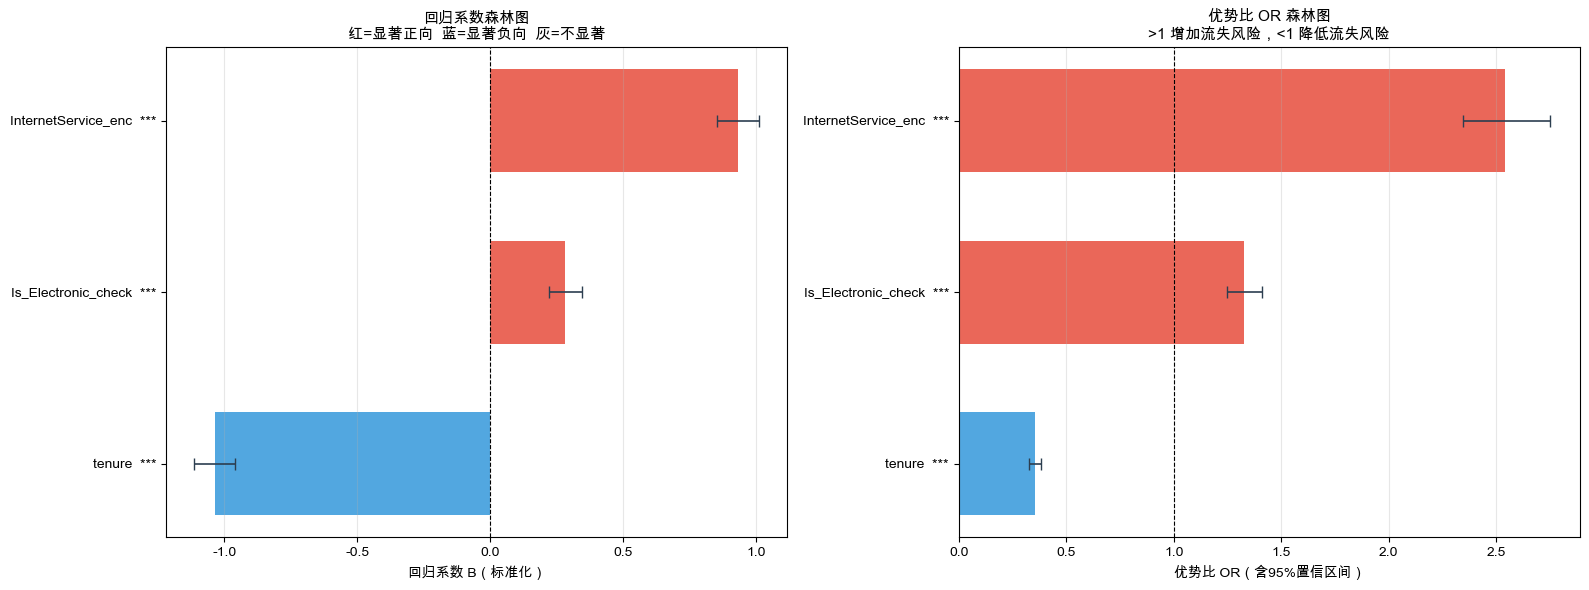

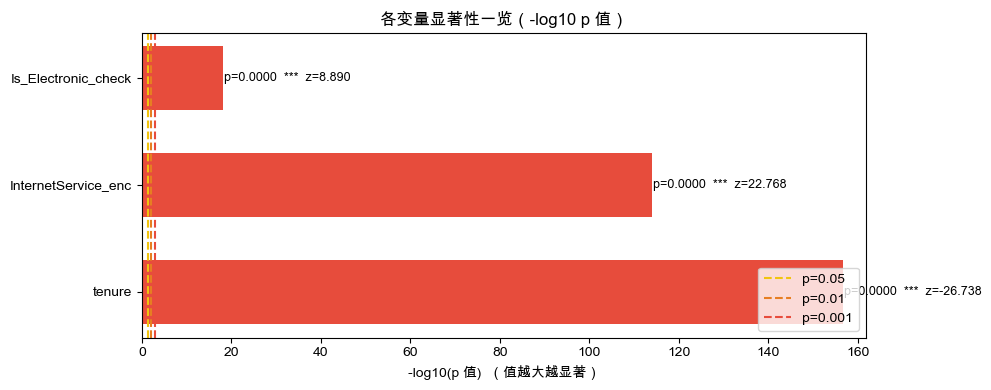

In [97]:
print("Logistic 回归重建模（删去不显著变量）")
print("-" * 40)

# 0) 基于上一版最终特征，先做字段兼容重命名
source_feature_cols = [
    'Pay_Electronic check' if c == 'Is_Electronic_check' else c
    for c in final_feature_cols
]
X_refit = df_model[source_feature_cols].astype(float).copy()

rename_map = {}
if 'Pay_Electronic check' in X_refit.columns:
    rename_map['Pay_Electronic check'] = 'Is_Electronic_check'
elif 'Pay_Electronic_check' in X_refit.columns:
    rename_map['Pay_Electronic_check'] = 'Is_Electronic_check'

X_refit = X_refit.rename(columns=rename_map)

# 1) 删除原模型中不显著变量，只保留重建模型核心特征
drop_candidates = [
    'Pay_Credit card',
    'Pay_Mailed check',
    'Pay_Credit_card',
    'Pay_Mailed_check',
    'SeniorCitizen',
    'Contract_enc'
 ]
drop_cols = [c for c in drop_candidates if c in X_refit.columns]
X_refit = X_refit.drop(columns=drop_cols, errors='ignore')

refit_feature_cols = list(X_refit.columns)
print(f"重命名后变量: {rename_map if rename_map else '无'}")
print(f"删除的不显著变量: {drop_cols if drop_cols else '无（未在特征集中匹配到）'}")
print(f"重建模特征集 ({len(refit_feature_cols)} 个): {refit_feature_cols}")

# 2) 为statsmodels进行标准化并添加截距项
scaler_refit = StandardScaler()
X_sc_refit = scaler_refit.fit_transform(X_refit)
X_sm_refit = sm.add_constant(X_sc_refit)
col_names_sm_refit = ['const'] + refit_feature_cols

# 3) 拟合重建Logit模型，输出完整统计量
logit_model_refit = sm.Logit(y, X_sm_refit)
result_refit = logit_model_refit.fit(disp=False)

coef_vals_refit = result_refit.params.values
std_errs_refit = result_refit.bse.values
z_vals_refit = result_refit.tvalues.values
p_vals_refit = result_refit.pvalues.values
ci_low_refit = result_refit.conf_int().iloc[:, 0].values
ci_high_refit = result_refit.conf_int().iloc[:, 1].values
or_vals_refit = np.exp(coef_vals_refit)

def sig_label_refit(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    elif p < 0.1: return '.'
    else: return 'ns'

stat_df_refit = pd.DataFrame({
    '变量':       col_names_sm_refit,
    '系数 B':     coef_vals_refit,
    '标准误 SE':  std_errs_refit,
    'z 值':       z_vals_refit,
    'p 值':       p_vals_refit,
    '显著性':     [sig_label_refit(p) for p in p_vals_refit],
    'OR':         or_vals_refit,
    '95%CI 下限': np.exp(ci_low_refit),
    '95%CI 上限': np.exp(ci_high_refit),
})

# 如果前序单元未定义打印函数，这里兜底定义
if 'print_aligned_table' not in globals():
    def print_aligned_table(df, float_digits=4):
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        formatters = {c: (lambda x, d=float_digits: f'{x:.{d}f}') for c in numeric_cols}
        col_space = {c: 12 for c in df.columns}
        if '变量' in col_space:
            col_space['变量'] = 24
        if '显著性' in col_space:
            col_space['显著性'] = 8
        print(df.to_string(index=False, justify='left', col_space=col_space, formatters=formatters))

print("\n重建模回归结果（含统计量）:")
print_aligned_table(stat_df_refit)
print("\n显著性标注说明: *** p<0.001  ** p<0.01  * p<0.05  . p<0.1  ns 不显著")

# 4) 输出重建模型拟合优度
print(f"\n模型整体拟合指标:")
print(f"  观测数:          {int(result_refit.nobs)}")
print(f"  对数似然值:      {result_refit.llf:.4f}")
print(f"  McFadden R²:     {result_refit.prsquared:.4f}")
print(f"  AIC:             {result_refit.aic:.4f}")
print(f"  BIC:             {result_refit.bic:.4f}")
print(f"  LR 检验 p 值:    {result_refit.llr_pvalue:.2e}")

# 5) 显著变量/不显著变量分开展示，便于解释
sig_vars_refit = stat_df_refit[stat_df_refit['变量'] != 'const'][
    stat_df_refit[stat_df_refit['变量'] != 'const']['p 值'] < 0.05]
insig_vars_refit = stat_df_refit[stat_df_refit['变量'] != 'const'][
    stat_df_refit[stat_df_refit['变量'] != 'const']['p 值'] >= 0.05]
print(f"\n显著变量（p < 0.05）:")
print_aligned_table(sig_vars_refit[['变量','系数 B','z 值','p 值','显著性','OR']])
print(f"\n不显著变量（p >= 0.05）:")
print_aligned_table(insig_vars_refit[['变量','系数 B','z 值','p 值','显著性','OR']])

# 6) 可视化：系数森林图 + OR森林图
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_df_refit = stat_df_refit[stat_df_refit['变量'] != 'const'].copy()
plot_df_refit['ci_low_raw'] = result_refit.conf_int().iloc[1:, 0].values
plot_df_refit['ci_high_raw'] = result_refit.conf_int().iloc[1:, 1].values
plot_df_refit['significant'] = plot_df_refit['p 值'] < 0.05
plot_df_refit = plot_df_refit.sort_values('系数 B')

colors_sig_refit = ['#e74c3c' if (sig and b > 0) else '#3498db' if (sig and b <= 0)
                    else '#bdc3c7'
                    for sig, b in zip(plot_df_refit['significant'], plot_df_refit['系数 B'])]

y_pos = range(len(plot_df_refit))
axes[0].barh(y_pos, plot_df_refit['系数 B'], color=colors_sig_refit, height=0.6, alpha=0.85)
axes[0].errorbar(plot_df_refit['系数 B'], y_pos,
                 xerr=[plot_df_refit['系数 B'] - plot_df_refit['ci_low_raw'],
                       plot_df_refit['ci_high_raw'] - plot_df_refit['系数 B']],
                 fmt='none', color='#2c3e50', capsize=4, linewidth=1.2)
axes[0].axvline(x=0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels([
    f"{row['变量']}  {row['显著性']}" for _, row in plot_df_refit.iterrows()
])
axes[0].set_xlabel('回归系数 B（标准化）')
axes[0].set_title('回归系数森林图\n红=显著正向  蓝=显著负向  灰=不显著', fontsize=11)
axes[0].grid(axis='x', alpha=0.3)

plot_df_or_refit = plot_df_refit.sort_values('OR')
y_pos2 = range(len(plot_df_or_refit))
colors_or_refit = ['#e74c3c' if (sig and o > 1) else '#3498db' if (sig and o <= 1)
                  else '#bdc3c7'
                  for sig, o in zip(plot_df_or_refit['significant'], plot_df_or_refit['OR'])]
axes[1].barh(y_pos2, plot_df_or_refit['OR'], color=colors_or_refit, height=0.6, alpha=0.85)
axes[1].errorbar(plot_df_or_refit['OR'], y_pos2,
                 xerr=[plot_df_or_refit['OR'] - plot_df_or_refit['95%CI 下限'],
                       plot_df_or_refit['95%CI 上限'] - plot_df_or_refit['OR']],
                 fmt='none', color='#2c3e50', capsize=4, linewidth=1.2)
axes[1].axvline(x=1, color='black', linewidth=0.8, linestyle='--')
axes[1].set_yticks(y_pos2)
axes[1].set_yticklabels([
    f"{row['变量']}  {row['显著性']}" for _, row in plot_df_or_refit.iterrows()
])
axes[1].set_xlabel('优势比 OR（含95%置信区间）')
axes[1].set_title('优势比 OR 森林图\n>1 增加流失风险，<1 降低流失风险', fontsize=11)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# 7) p值热图辅助解释统计显著程度
fig, ax = plt.subplots(figsize=(10, 4))
plot_p_refit = stat_df_refit[stat_df_refit['变量'] != 'const'][['变量', 'p 值', '显著性', 'z 值', '系数 B']].copy()
plot_p_refit = plot_p_refit.sort_values('p 值')
bar_colors_p_refit = ['#e74c3c' if p < 0.001 else '#e67e22' if p < 0.01
                      else '#f1c40f' if p < 0.05 else '#95a5a6' for p in plot_p_refit['p 值']]
bars_p_refit = ax.barh(plot_p_refit['变量'], -np.log10(plot_p_refit['p 值'].clip(lower=1e-300)),
                       color=bar_colors_p_refit, height=0.6)
ax.axvline(x=-np.log10(0.05), color='#f1c40f', linestyle='--', linewidth=1.5, label='p=0.05')
ax.axvline(x=-np.log10(0.01), color='#e67e22', linestyle='--', linewidth=1.5, label='p=0.01')
ax.axvline(x=-np.log10(0.001), color='#e74c3c', linestyle='--', linewidth=1.5, label='p=0.001')
for bar, (_, row) in zip(bars_p_refit, plot_p_refit.iterrows()):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f"p={row['p 值']:.4f}  {row['显著性']}  z={row['z 值']:.3f}",
            va='center', fontsize=9)
ax.set_xlabel('-log10(p 值)  （值越大越显著）')
ax.set_title('各变量显著性一览（-log10 p 值）')
ax.legend(loc='lower right')
ax.set_xlim(0, max(-np.log10(plot_p_refit['p 值'].clip(lower=1e-300))) + 5)
plt.tight_layout()
plt.show()

# 8) 覆盖关键变量，便于后续单元沿用重建模结果
X = X_refit
scaler = scaler_refit
result = result_refit
stat_df = stat_df_refit
sig_vars = sig_vars_refit
insig_vars = insig_vars_refit
final_feature_cols = refit_feature_cols

### 6.2. 模型预测评估与交叉验证

重建模型预测评估与交叉验证（3个核心特征）
----------------------------------------
使用特征: ['tenure', 'InternetService_enc', 'Is_Electronic_check']
测试集 AUC-ROC: 0.8345
决策阈值: 0.35
当前阈值对应: TPR=0.8840, FPR=0.4280

分类报告（测试集）:
类别         precision  recall     f1-score   support 
      未流失 0.9322     0.5720     0.7090     1514    
        流失 0.4255     0.8840     0.5745      543    
   macro avg 0.6789     0.7280     0.6417     2057    
weighted avg 0.7984     0.6544     0.6735     2057    

Accuracy: 0.6544

候选阈值 TPR/FPR 一览（测试集）:
阈值     TPR        FPR       
0.30     0.9263     0.4993    
0.35     0.8840     0.4280    
0.40     0.8490     0.3719    
0.50     0.7901     0.2840    
0.60     0.6906     0.1902    

5折交叉验证结果（流失类）:
折次     AUC        召回率     精确率     F1        
 第1折   0.8261     0.7535     0.5028     0.6031    
 第2折   0.8408     0.8089     0.5214     0.6341    
 第3折   0.8105     0.7459     0.4927     0.5934    
 第4折   0.8408     0.7845     0.5136     0.6208    
 第5折   0.8109     0.7486     0.5075     0.

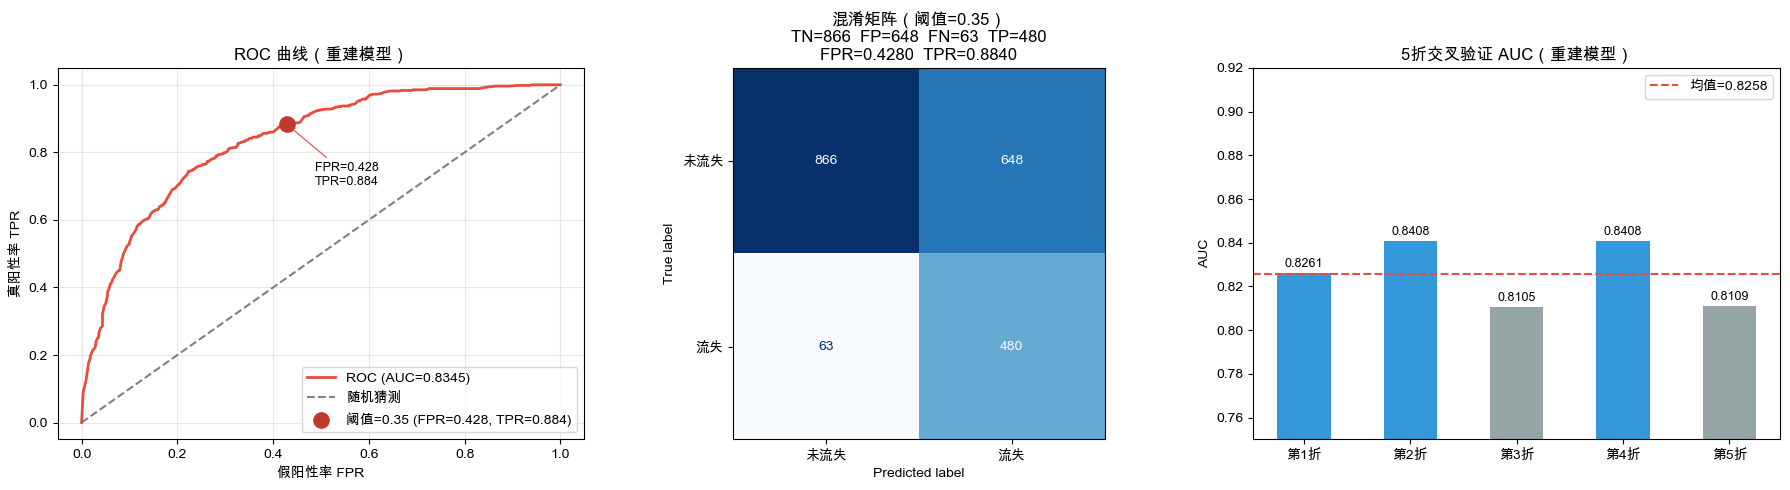

In [95]:
print("重建模型预测评估与交叉验证（3个核心特征）")
print("-" * 40)

# 用 sklearn 做预测评估和交叉验证（与 statsmodels 参数保持一致）
from sklearn.linear_model import LogisticRegression

# 0) 读取重建模型特征，并声明评估对象
X_eval_refit = X_refit.copy()
print(f"使用特征: {list(X_eval_refit.columns)}")
scaler_eval_refit = StandardScaler()

# 1) 分层切分训练/测试，保证流失比例稳定
X_train_refit_eval, X_test_refit_eval, y_train_refit_eval, y_test_refit_eval = train_test_split(
    X_eval_refit, y, test_size=0.3, random_state=42, stratify=y)
X_train_sc_refit_eval = scaler_eval_refit.fit_transform(X_train_refit_eval)
X_test_sc_refit_eval = scaler_eval_refit.transform(X_test_refit_eval)

# 2) 训练重建模型并得到测试集概率输出
clf_eval_refit = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
clf_eval_refit.fit(X_train_sc_refit_eval, y_train_refit_eval)

y_pred_proba_refit_eval = clf_eval_refit.predict_proba(X_test_sc_refit_eval)[:, 1]
auc_test_refit_eval = roc_auc_score(y_test_refit_eval, y_pred_proba_refit_eval)

# 3) 先按默认业务阈值评估，和后续阈值优化隔离
THRESHOLD_REFIT = 0.35
y_pred_refit_eval = (y_pred_proba_refit_eval >= THRESHOLD_REFIT).astype(int)

# 4) 当前阈值下的混淆矩阵 + TPR/FPR
cm_refit_eval = confusion_matrix(y_test_refit_eval, y_pred_refit_eval)
tn_refit_eval, fp_refit_eval, fn_refit_eval, tp_refit_eval = cm_refit_eval.ravel()
tpr_refit_at_threshold = tp_refit_eval / (tp_refit_eval + fn_refit_eval) if (tp_refit_eval + fn_refit_eval) > 0 else 0.0
fpr_refit_at_threshold = fp_refit_eval / (fp_refit_eval + tn_refit_eval) if (fp_refit_eval + tn_refit_eval) > 0 else 0.0

print(f"测试集 AUC-ROC: {auc_test_refit_eval:.4f}")
print(f"决策阈值: {THRESHOLD_REFIT}")
print(f"当前阈值对应: TPR={tpr_refit_at_threshold:.4f}, FPR={fpr_refit_at_threshold:.4f}")
print("\n分类报告（测试集）:")
report_dict_refit_eval = classification_report(
    y_test_refit_eval, y_pred_refit_eval, target_names=['未流失', '流失'], output_dict=True
)
accuracy_test_refit_eval = report_dict_refit_eval.pop('accuracy')
cls_report_df_refit_eval = pd.DataFrame(report_dict_refit_eval).T
cls_report_df_refit_eval.index.name = '类别'
cls_report_df_refit_eval = cls_report_df_refit_eval.reset_index()
print(cls_report_df_refit_eval.to_string(
    index=False,
    justify='left',
    col_space={'类别': 12, 'precision': 10, 'recall': 10, 'f1-score': 10, 'support': 8},
    formatters={
        'precision': lambda x: f'{x:.4f}' if isinstance(x, (float, np.floating)) else x,
        'recall': lambda x: f'{x:.4f}' if isinstance(x, (float, np.floating)) else x,
        'f1-score': lambda x: f'{x:.4f}' if isinstance(x, (float, np.floating)) else x,
        'support': lambda x: f'{int(round(x))}' if isinstance(x, (float, np.floating, int, np.integer)) else x
    }
) )
print(f"\nAccuracy: {accuracy_test_refit_eval:.4f}")

# 5) 给出候选阈值TPR/FPR表，便于观察误报-召回权衡
threshold_candidates_refit = [0.30, 0.35, 0.40, 0.50, 0.60]
rows_tpr_fpr_refit = []
for th in threshold_candidates_refit:
    y_pred_th = (y_pred_proba_refit_eval >= th).astype(int)
    tn_th, fp_th, fn_th, tp_th = confusion_matrix(y_test_refit_eval, y_pred_th).ravel()
    tpr_th = tp_th / (tp_th + fn_th) if (tp_th + fn_th) > 0 else 0.0
    fpr_th = fp_th / (fp_th + tn_th) if (fp_th + tn_th) > 0 else 0.0
    rows_tpr_fpr_refit.append([th, tpr_th, fpr_th])
tpr_fpr_table_refit = pd.DataFrame(rows_tpr_fpr_refit, columns=['阈值', 'TPR', 'FPR'])
print("\n候选阈值 TPR/FPR 一览（测试集）:")
print(tpr_fpr_table_refit.to_string(
    index=False,
    justify='left',
    col_space={'阈值': 8, 'TPR': 10, 'FPR': 10},
    formatters={
        '阈值': lambda x: f'{x:.2f}',
        'TPR': lambda x: f'{x:.4f}',
        'FPR': lambda x: f'{x:.4f}'
    }
) )

# 6) 5折交叉验证评估稳定性（均值+标准差）
X_all_sc_refit_eval = scaler_eval_refit.fit_transform(X_eval_refit)
cv_refit_eval = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc_refit_eval = cross_val_score(clf_eval_refit, X_all_sc_refit_eval, y, cv=cv_refit_eval, scoring='roc_auc')
cv_rec_refit_eval = cross_val_score(clf_eval_refit, X_all_sc_refit_eval, y, cv=cv_refit_eval, scoring='recall')
cv_prec_refit_eval = cross_val_score(clf_eval_refit, X_all_sc_refit_eval, y, cv=cv_refit_eval, scoring='precision')
cv_f1_refit_eval = cross_val_score(clf_eval_refit, X_all_sc_refit_eval, y, cv=cv_refit_eval, scoring='f1')

print("\n5折交叉验证结果（流失类）:")
rows_refit_eval = []
for i in range(5):
    rows_refit_eval.append([f'第{i+1}折', cv_auc_refit_eval[i], cv_rec_refit_eval[i], cv_prec_refit_eval[i], cv_f1_refit_eval[i]])
rows_refit_eval.append(['均值', cv_auc_refit_eval.mean(), cv_rec_refit_eval.mean(), cv_prec_refit_eval.mean(), cv_f1_refit_eval.mean()])
rows_refit_eval.append(['标准差', cv_auc_refit_eval.std(), cv_rec_refit_eval.std(), cv_prec_refit_eval.std(), cv_f1_refit_eval.std()])
cv_table_refit_eval = pd.DataFrame(rows_refit_eval, columns=['折次', 'AUC', '召回率', '精确率', 'F1'])
print(cv_table_refit_eval.to_string(
    index=False,
    justify='left',
    col_space={'折次': 8, 'AUC': 10, '召回率': 10, '精确率': 10, 'F1': 10},
    formatters={
        'AUC': lambda x: f'{x:.4f}' if isinstance(x, (float, np.floating)) else x,
        '召回率': lambda x: f'{x:.4f}' if isinstance(x, (float, np.floating)) else x,
        '精确率': lambda x: f'{x:.4f}' if isinstance(x, (float, np.floating)) else x,
        'F1': lambda x: f'{x:.4f}' if isinstance(x, (float, np.floating)) else x
    }
) )

# 7) 可视化汇总：ROC + 混淆矩阵 + CV AUC
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fpr_refit_eval, tpr_refit_eval, thresholds_roc_refit_eval = roc_curve(y_test_refit_eval, y_pred_proba_refit_eval)
axes[0].plot(fpr_refit_eval, tpr_refit_eval, color='#e74c3c', lw=2,
             label=f'ROC (AUC={auc_test_refit_eval:.4f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', label='随机猜测')
idx_refit_eval = np.argmin(np.abs(thresholds_roc_refit_eval - THRESHOLD_REFIT))
axes[0].scatter(
    fpr_refit_at_threshold, tpr_refit_at_threshold, s=120, color='#c0392b', zorder=5,
    label=f'阈值={THRESHOLD_REFIT} (FPR={fpr_refit_at_threshold:.3f}, TPR={tpr_refit_at_threshold:.3f})'
 )
axes[0].annotate(
    f'FPR={fpr_refit_at_threshold:.3f}\nTPR={tpr_refit_at_threshold:.3f}',
    xy=(fpr_refit_at_threshold, tpr_refit_at_threshold),
    xytext=(fpr_refit_at_threshold + 0.06, max(0.05, tpr_refit_at_threshold - 0.18)),
    arrowprops=dict(arrowstyle='->', color='#c0392b', alpha=0.7),
    fontsize=9
 )
axes[0].set_xlabel('假阳性率 FPR')
axes[0].set_ylabel('真阳性率 TPR')
axes[0].set_title('ROC 曲线（重建模型）')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

disp_refit_eval = ConfusionMatrixDisplay(confusion_matrix=cm_refit_eval, display_labels=['未流失', '流失'])
disp_refit_eval.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(
    f'混淆矩阵（阈值={THRESHOLD_REFIT}）\nTN={tn_refit_eval}  FP={fp_refit_eval}  FN={fn_refit_eval}  TP={tp_refit_eval}\n'
    f'FPR={fpr_refit_at_threshold:.4f}  TPR={tpr_refit_at_threshold:.4f}'
)

fold_labels_refit_eval = [f'第{i+1}折' for i in range(5)]
bar_cols_refit_eval = ['#3498db' if v >= cv_auc_refit_eval.mean() else '#95a5a6' for v in cv_auc_refit_eval]
axes[2].bar(fold_labels_refit_eval, cv_auc_refit_eval, color=bar_cols_refit_eval, width=0.5)
axes[2].axhline(y=cv_auc_refit_eval.mean(), color='#e74c3c', linestyle='--',
                label=f'均值={cv_auc_refit_eval.mean():.4f}')
axes[2].set_ylim(0.75, 0.92)
axes[2].set_ylabel('AUC')
axes[2].set_title('5折交叉验证 AUC（重建模型）')
axes[2].legend()
for i, v in enumerate(cv_auc_refit_eval):
    axes[2].text(i, v + 0.003, f'{v:.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# 8) 保留关键评估对象给后续单元复用（结果分析/阈值分析）
auc_test_refit = auc_test_refit_eval
cv_auc_refit = cv_auc_refit_eval
y_test_refit = y_test_refit_eval
y_pred_refit = y_pred_refit_eval

### 6.3. 新模型阈值选择（Precision / Recall / F1）

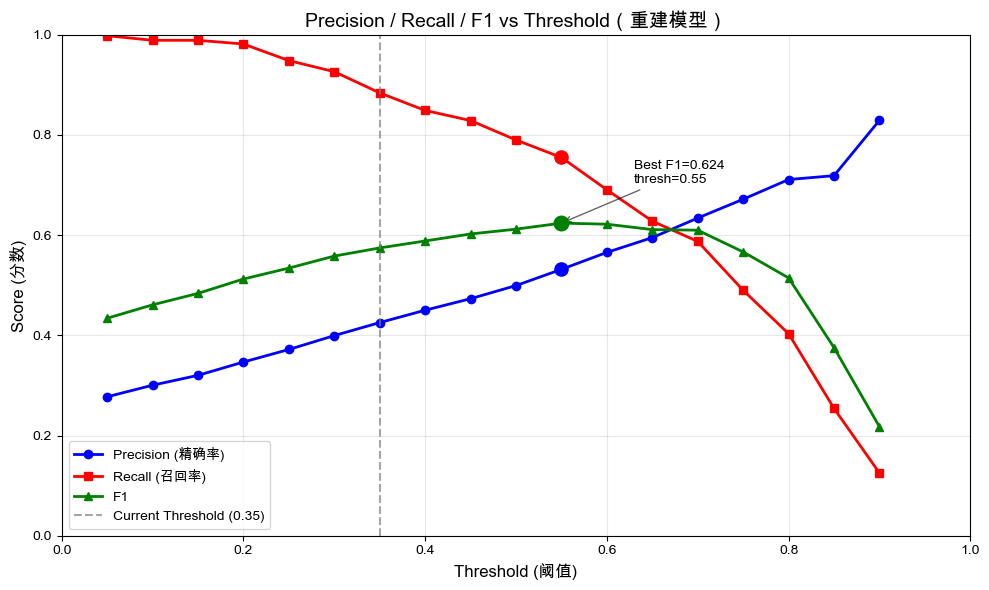

当前评估对象: 重建模型
最佳F1阈值: 0.55
此时精确率: 0.532, 召回率: 0.755, F1: 0.624

Top-3 阈值（按 F1 排序）:
1. 阈值=0.55 | Precision=0.532 | Recall=0.755 | F1=0.624
2. 阈值=0.60 | Precision=0.566 | Recall=0.691 | F1=0.622
3. 阈值=0.50 | Precision=0.499 | Recall=0.790 | F1=0.612


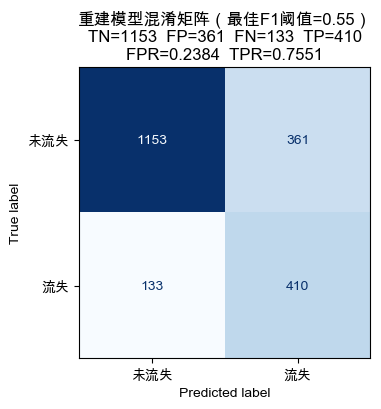


重建模型四档风险分层：
风险档位   概率区间               定义依据             
  高风险          P >= 0.70       precision >= 60% 锚点
较高风险   0.55 <= P < 0.70                F1 最高 锚点
中等风险   0.30 <= P < 0.55             recall 90% 锚点
  低风险           P < 0.30                最低风险区间

测试集样本分布：
高风险      503
较高风险    268
中等风险    488
低风险      798


In [93]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

# 自动选择可用评估对象：优先重建模型，回退到原模型
if 'y_test_refit_eval' in globals() and 'y_pred_proba_refit_eval' in globals():
    y_true = y_test_refit_eval
    y_prob = y_pred_proba_refit_eval
    model_tag = '重建模型'
    current_thresh = THRESHOLD_REFIT if 'THRESHOLD_REFIT' in globals() else 0.35
elif 'y_test_base' in globals() and 'y_pred_proba_base' in globals():
    y_true = y_test_base
    y_prob = y_pred_proba_base
    model_tag = '原模型'
    current_thresh = THRESHOLD_BASE if 'THRESHOLD_BASE' in globals() else 0.35
else:
    raise NameError('未找到可用的 y_true / y_prob，请先运行模型评估单元。')

# 1) 统一阈值网格，逐点计算 Precision / Recall / F1
thresholds = np.arange(0.05, 0.95, 0.05)
precisions = []
recalls = []
f1_scores = []

for thresh in thresholds:
    y_pred = (y_prob >= thresh).astype(int)
    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0
    precisions.append(p)
    recalls.append(r)
    f1_scores.append(f1)

# 2) 选择F1最高阈值，作为当前模型的推荐阈值
best_idx = int(np.argmax(f1_scores))
best_thresh = float(thresholds[best_idx])

# 3) 可视化对比三条曲线，同时标出当前阈值与最佳阈值
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions, 'b-', marker='o', label='Precision (精确率)', linewidth=2)
plt.plot(thresholds, recalls, 'r-', marker='s', label='Recall (召回率)', linewidth=2)
plt.plot(thresholds, f1_scores, 'g-', marker='^', label='F1', linewidth=2)

plt.axvline(
    x=current_thresh,
    color='gray',
    linestyle='--',
    alpha=0.7,
    label=f'Current Threshold ({current_thresh:.2f})'
 )

plt.scatter(best_thresh, precisions[best_idx], color='blue', s=90, zorder=5)
plt.scatter(best_thresh, recalls[best_idx], color='red', s=90, zorder=5)
plt.scatter(best_thresh, f1_scores[best_idx], color='green', s=110, zorder=6)
plt.annotate(
    f'Best F1={f1_scores[best_idx]:.3f}\nthresh={best_thresh:.2f}',
    xy=(best_thresh, f1_scores[best_idx]),
    xytext=(best_thresh + 0.08, min(0.98, f1_scores[best_idx] + 0.08)),
    arrowprops=dict(arrowstyle='->', color='black', alpha=0.6),
    fontsize=10
 )

plt.xlabel('Threshold (阈值)', fontsize=12)
plt.ylabel('Score (分数)', fontsize=12)
plt.title(f'Precision / Recall / F1 vs Threshold（{model_tag}）', fontsize=14)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print(f'当前评估对象: {model_tag}')
print(f'最佳F1阈值: {best_thresh:.2f}')
print(f'此时精确率: {precisions[best_idx]:.3f}, 召回率: {recalls[best_idx]:.3f}, F1: {f1_scores[best_idx]:.3f}')

# 4) 输出Top-3阈值，便于业务场景做阈值取舍
top_idx = np.argsort(f1_scores)[::-1][:3]
print('\nTop-3 阈值（按 F1 排序）:')
for rank, idx in enumerate(top_idx, start=1):
    print(
        f'{rank}. 阈值={thresholds[idx]:.2f} | Precision={precisions[idx]:.3f} | Recall={recalls[idx]:.3f} | F1={f1_scores[idx]:.3f}'
    )

# 5) 用最佳阈值重算混淆矩阵，并输出TPR/FPR便于解释误报与漏报
y_pred_best = (y_prob >= best_thresh).astype(int)
cm_best = confusion_matrix(y_true, y_pred_best)
tn_best, fp_best, fn_best, tp_best = cm_best.ravel()
tpr_best = tp_best / (tp_best + fn_best) if (tp_best + fn_best) > 0 else 0.0
fpr_best = fp_best / (fp_best + tn_best) if (fp_best + tn_best) > 0 else 0.0
fig, ax = plt.subplots(figsize=(5.2, 4.2))
disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=['未流失', '流失'])
disp_best.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'{model_tag}混淆矩阵（最佳F1阈值={best_thresh:.2f}）\nTN={tn_best}  FP={fp_best}  FN={fn_best}  TP={tp_best}\nFPR={fpr_best:.4f}  TPR={tpr_best:.4f}')
plt.tight_layout()
plt.show()

# 6) 基于三个位点构建四档风险分层（用于运营分级触达）
recall_target = 0.90
precision_target = 0.60
recall_candidates = np.where(np.array(recalls) >= recall_target)[0]
precision_candidates = np.where(np.array(precisions) >= precision_target)[0]
recall90_idx = int(recall_candidates.max()) if len(recall_candidates) else int(np.argmax(recalls))
precision60_idx = int(precision_candidates.min()) if len(precision_candidates) else int(np.argmax(precisions))
f1_best_idx = best_idx
anchor_thresholds = {
    'recall_90': float(thresholds[recall90_idx]),
    'f1_best': float(thresholds[f1_best_idx]),
    'precision_60': float(thresholds[precision60_idx]),
}
anchor_order = sorted(anchor_thresholds.items(), key=lambda kv: kv[1])
ordered_threshold_values = [v for _, v in anchor_order]
if ordered_threshold_values != [anchor_thresholds['recall_90'], anchor_thresholds['f1_best'], anchor_thresholds['precision_60']]:
    print('\n提示：当前三个位点的顺序不是 recall90 < F1最佳 < precision60，已按数值顺序重排分层边界。')
low_cut, mid_cut, high_cut = ordered_threshold_values
risk_labels = np.select(
    [y_prob >= high_cut, y_prob >= mid_cut, y_prob >= low_cut],
    ['高风险', '较高风险', '中等风险'],
    default='低风险'
)
risk_tier_table = pd.DataFrame([
    ['高风险', f'P >= {high_cut:.2f}', 'precision >= 60% 锚点'],
    ['较高风险', f'{mid_cut:.2f} <= P < {high_cut:.2f}', 'F1 最高 锚点'],
    ['中等风险', f'{low_cut:.2f} <= P < {mid_cut:.2f}', 'recall 90% 锚点'],
    ['低风险', f'P < {low_cut:.2f}', '最低风险区间'],
], columns=['风险档位', '概率区间', '定义依据'])
risk_tier_count = pd.Series(risk_labels).value_counts().reindex(['高风险', '较高风险', '中等风险', '低风险']).fillna(0).astype(int)
print('\n重建模型四档风险分层：')
print(risk_tier_table.to_string(index=False, justify='left', col_space={'风险档位': 10, '概率区间': 22, '定义依据': 18}))
print('\n测试集样本分布：')
print(risk_tier_count.to_string())

## 7. 结果分析

In [100]:
print("原模型 / 重建模型 对比分析（含最佳阈值）")
print("=" * 72)

# 0) 先汇总默认阈值（0.35）下两套模型的核心指标
report_dict_base = classification_report(
    y_test_base, y_pred_base, target_names=['未流失', '流失'], output_dict=True)
churn_recall_base = report_dict_base['流失']['recall']
churn_precision_base = report_dict_base['流失']['precision']
churn_f1_val_base = report_dict_base['流失']['f1-score']
accuracy_base = report_dict_base['accuracy']

report_dict_refit = classification_report(
    y_test_refit, y_pred_refit, target_names=['未流失', '流失'], output_dict=True)
churn_recall_refit = report_dict_refit['流失']['recall']
churn_precision_refit = report_dict_refit['流失']['precision']
churn_f1_val_refit = report_dict_refit['流失']['f1-score']
accuracy_refit = report_dict_refit['accuracy']

# 1) 读取最佳阈值（若阈值单元未运行则回退默认阈值）
best_thresh_base_eval = best_thresh_base if 'best_thresh_base' in globals() else THRESHOLD_BASE
best_thresh_refit_eval = best_thresh if 'best_thresh' in globals() else THRESHOLD_REFIT

# 2) 计算“最佳阈值”下的分类结果，便于与默认阈值做对比
y_pred_base_best_eval = (y_pred_proba_base >= best_thresh_base_eval).astype(int)
report_dict_base_best = classification_report(
    y_test_base, y_pred_base_best_eval, target_names=['未流失', '流失'], output_dict=True)
churn_recall_base_best = report_dict_base_best['流失']['recall']
churn_precision_base_best = report_dict_base_best['流失']['precision']
churn_f1_base_best = report_dict_base_best['流失']['f1-score']
accuracy_base_best = report_dict_base_best['accuracy']

y_pred_refit_best_eval = (y_pred_proba_refit_eval >= best_thresh_refit_eval).astype(int)
report_dict_refit_best = classification_report(
    y_test_refit_eval, y_pred_refit_best_eval, target_names=['未流失', '流失'], output_dict=True)
churn_recall_refit_best = report_dict_refit_best['流失']['recall']
churn_precision_refit_best = report_dict_refit_best['流失']['precision']
churn_f1_refit_best = report_dict_refit_best['流失']['f1-score']
accuracy_refit_best = report_dict_refit_best['accuracy']

# 3) 用一段结构化文本统一输出：数据质量、模型对比、阈值收益与业务建议
print(f"""
1. 数据质量
   数据共 {df.shape[0]} 条，去重后剩余 {df_model.shape[0]} 条。
   无缺失值，数值变量无异常值，数据质量良好。

2. 默认阈值下模型对比（当前阈值均为0.35）
   原模型：AUC={auc_test_base:.4f}，Accuracy={accuracy_base:.4f}，流失召回率={churn_recall_base:.1%}，
          流失精确率={churn_precision_base:.1%}，流失F1={churn_f1_val_base:.4f}。
   重建模型：AUC={auc_test_refit:.4f}，Accuracy={accuracy_refit:.4f}，流失召回率={churn_recall_refit:.1%}，
            流失精确率={churn_precision_refit:.1%}，流失F1={churn_f1_val_refit:.4f}。

3. 最佳阈值后模型对比（来自5.3与6.3）
   原模型最佳阈值={best_thresh_base_eval:.2f}：Accuracy={accuracy_base_best:.4f}，
      流失精确率={churn_precision_base_best:.1%}，流失召回率={churn_recall_base_best:.1%}，流失F1={churn_f1_base_best:.4f}。
   重建模型最佳阈值={best_thresh_refit_eval:.2f}：Accuracy={accuracy_refit_best:.4f}，
      流失精确率={churn_precision_refit_best:.1%}，流失召回率={churn_recall_refit_best:.1%}，流失F1={churn_f1_refit_best:.4f}。

4. 阈值优化带来的变化（最佳阈值 - 默认阈值）
   原模型：Accuracy {accuracy_base_best - accuracy_base:+.4f}，
      Precision {churn_precision_base_best - churn_precision_base:+.1%}，
      Recall {churn_recall_base_best - churn_recall_base:+.1%}，
      F1 {churn_f1_base_best - churn_f1_val_base:+.4f}。
   重建模型：Accuracy {accuracy_refit_best - accuracy_refit:+.4f}，
      Precision {churn_precision_refit_best - churn_precision_refit:+.1%}，
      Recall {churn_recall_refit_best - churn_recall_refit:+.1%}，
      F1 {churn_f1_refit_best - churn_f1_val_refit:+.4f}。

5. 变量与业务解读
   原模型解释面更广（合约、支付方式、老年客户、网络类型、在网时长）；
   重建模型聚焦核心驱动（在网时长、网络类型、电子支票），解释更简洁。
   结合阈值优化结果，原模型在F1上略优，重建模型在可解释性与部署简洁性上更有优势。

6. 业务建议
   (1) 若目标是提升流失客户识别质量，可优先采用“各模型最佳阈值”而非固定0.35。
   (2) 对原模型可使用约0.60阈值，降低误报并保持较高召回。
   (3) 对重建模型可使用约0.55阈值，在精确率与召回率之间取得更稳平衡。
   (4) 针对高风险客户（光纤+电子支票+低tenure）建立分层挽留策略。
   (5) 可将预测概率继续拆成四档：低风险、中等风险、较高风险、高风险。
       其中低风险对应低于 recall 90% 锚点，中等风险位于 recall 90% 与 F1 最优之间，
       较高风险位于 F1 最优与 precision 60% 之间，高风险对应高于 precision 60% 锚点。
       这样可以把一次性阈值判断，变成不同触达强度的运营分层。
""")

原模型 / 重建模型 对比分析（含最佳阈值）

1. 数据质量
   数据共 6855 条，去重后剩余 6855 条。
   无缺失值，数值变量无异常值，数据质量良好。

2. 默认阈值下模型对比（当前阈值均为0.35）
   原模型：AUC=0.8438，Accuracy=0.6578，流失召回率=91.3%，
          流失精确率=43.0%，流失F1=0.5849。
   重建模型：AUC=0.8345，Accuracy=0.6544，流失召回率=88.4%，
            流失精确率=42.6%，流失F1=0.5745。

3. 最佳阈值后模型对比（来自5.3与6.3）
   原模型最佳阈值=0.60：Accuracy=0.7769，
      流失精确率=55.9%，流失召回率=73.7%，流失F1=0.6354。
   重建模型最佳阈值=0.55：Accuracy=0.7598，
      流失精确率=53.2%，流失召回率=75.5%，流失F1=0.6240。

4. 阈值优化带来的变化（最佳阈值 - 默认阈值）
   原模型：Accuracy +0.1191，
      Precision +12.8%，
      Recall -17.7%，
      F1 +0.0505。
   重建模型：Accuracy +0.1055，
      Precision +10.6%，
      Recall -12.9%，
      F1 +0.0495。

5. 变量与业务解读
   原模型解释面更广（合约、支付方式、老年客户、网络类型、在网时长）；
   重建模型聚焦核心驱动（在网时长、网络类型、电子支票），解释更简洁。
   结合阈值优化结果，原模型在F1上略优，重建模型在可解释性与部署简洁性上更有优势。

6. 业务建议
   (1) 若目标是提升流失客户识别质量，可优先采用“各模型最佳阈值”而非固定0.35。
   (2) 对原模型可使用约0.60阈值，降低误报并保持较高召回。
   (3) 对重建模型可使用约0.55阈值，在精确率与召回率之间取得更稳平衡。
   (4) 针对高风险客户（光纤+电子支票+低tenure）建立分层挽留策略。
   (5) 可将预测概率继续拆成四档：低风险、中等风险、较高风险、高风险。

In [ ]:
# # 8. 在线验证函数：输入原始6个参数，同时输出原模型与新模型流失率
# def predict_churn_rate_from_raw(
#     senior_citizen,
#     tenure,
#     internet_service,
#     contract,
#     payment_method,
#     monthly_charges=None,
# ):
#     """
#     使用同一组业务侧原始字段，同时输出：
#     - 原模型（base_pipe）的预测流失率
#     - 新模型（clf_eval_refit + scaler_eval_refit）的预测流失率

#     参数说明：
#     - senior_citizen: 是否老年客户（0/1）
#     - tenure: 在网时长（月）
#     - internet_service: 网络类型（No / DSL / Fiber optic）
#     - contract: 合约类型（Month-to-month / One year / Two year）
#     - payment_method: 支付方式（如 Electronic check / Credit card / Mailed check）
#     - monthly_charges: 兼容入参（当前两个模型均未直接使用该变量）
#     """
#     internet_map = {'No': 0, 'DSL': 1, 'Fiber optic': 2}
#     contract_map = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}

#     if internet_service not in internet_map:
#         raise ValueError(f"internet_service 无效: {internet_service}，可选 {list(internet_map.keys())}")
#     if contract not in contract_map:
#         raise ValueError(f"contract 无效: {contract}，可选 {list(contract_map.keys())}")

#     pm_norm = str(payment_method).strip().lower().replace('-', ' ').replace('_', ' ')

#     # -------- 原模型预测 --------
#     if 'base_pipe' not in globals() or 'original_feature_cols' not in globals():
#         raise NameError("请先运行第16个代码单元（原模型评估与交叉验证），以加载 base_pipe 和特征定义。")

#     x_row_base = {col: 0.0 for col in original_feature_cols}
#     if 'SeniorCitizen' in x_row_base:
#         x_row_base['SeniorCitizen'] = float(int(senior_citizen))
#     if 'tenure' in x_row_base:
#         x_row_base['tenure'] = float(tenure)
#     if 'InternetService_enc' in x_row_base:
#         x_row_base['InternetService_enc'] = float(internet_map[internet_service])
#     if 'Contract_enc' in x_row_base:
#         x_row_base['Contract_enc'] = float(contract_map[contract])

#     pay_cols_base = [c for c in original_feature_cols if c.startswith('Pay_')]
#     pay_col_exact = f"Pay_{payment_method}"
#     if pay_col_exact in pay_cols_base:
#         x_row_base[pay_col_exact] = 1.0
#     else:
#         matched_cols = [
#             c for c in pay_cols_base
#             if pm_norm == c.replace('Pay_', '').strip().lower().replace('-', ' ').replace('_', ' ')
#         ]
#         if len(matched_cols) == 1:
#             x_row_base[matched_cols[0]] = 1.0
#         elif len(matched_cols) > 1:
#             raise ValueError(f"payment_method 匹配到多个原模型列: {matched_cols}，请使用更精确的支付方式名称。")
#         # 无匹配时按基准类处理（所有Pay_*为0）

#     x_input_base = pd.DataFrame([x_row_base], columns=original_feature_cols)
#     churn_rate_base = float(base_pipe.predict_proba(x_input_base)[:, 1][0])

#     # -------- 新模型预测 --------
#     if 'clf_eval_refit' not in globals() or 'scaler_eval_refit' not in globals():
#         raise NameError("请先运行第23个代码单元（重建模型评估与交叉验证），以加载新模型对象。")

#     if 'refit_feature_cols' in globals():
#         refit_cols = list(refit_feature_cols)
#     elif 'X_eval_refit' in globals():
#         refit_cols = list(X_eval_refit.columns)
#     else:
#         raise NameError("未找到新模型特征列，请先运行第21或第23个代码单元。")

#     x_row_refit = {col: 0.0 for col in refit_cols}
#     if 'SeniorCitizen' in x_row_refit:
#         x_row_refit['SeniorCitizen'] = float(int(senior_citizen))
#     if 'tenure' in x_row_refit:
#         x_row_refit['tenure'] = float(tenure)
#     if 'InternetService_enc' in x_row_refit:
#         x_row_refit['InternetService_enc'] = float(internet_map[internet_service])
#     if 'Contract_enc' in x_row_refit:
#         x_row_refit['Contract_enc'] = float(contract_map[contract])

#     # 新模型中的电子支票特征兼容处理
#     is_electronic = 1.0 if pm_norm == 'electronic check' else 0.0
#     for ele_col in ['Is_Electronic_check', 'Pay_Electronic check', 'Pay_Electronic_check']:
#         if ele_col in x_row_refit:
#             x_row_refit[ele_col] = is_electronic

#     x_input_refit = pd.DataFrame([x_row_refit], columns=refit_cols)
#     x_input_refit_sc = scaler_eval_refit.transform(x_input_refit)
#     churn_rate_refit = float(clf_eval_refit.predict_proba(x_input_refit_sc)[:, 1][0])

#     print(f"原模型预测流失率: {churn_rate_base:.2%}")
#     print(f"新模型预测流失率: {churn_rate_refit:.2%}")
#     if monthly_charges is not None:
#         print("提示: monthly_charges 已接收，但当前这两个模型均未直接使用该变量。")

#     return {
#         'original_model_churn_rate': churn_rate_base,
#         'refit_model_churn_rate': churn_rate_refit,
#     }

# # 使用示例（取消注释即可测试）
# _ = predict_churn_rate_from_raw(
#     senior_citizen=1,
#     tenure=24,
#     internet_service='DSL',
#     contract='One year',
#     payment_method='Credit card',
#     monthly_charges=33,
# )

原模型预测流失率: 36.38%
新模型预测流失率: 36.14%
提示: monthly_charges 已接收，但当前这两个模型均未直接使用该变量。
